In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import math
import os

from statsmodels.miscmodels.ordinal_model import OrderedModel

%load_ext autoreload
%autoreload 2

import utils.columns as cols
import utils.transform as transform
import utils.univariate as univar
import utils.bivariate as bivar
import utils.ordinal_regression as ordinal
import utils.experiment as experiment


# Read Preprocessed Mental, Social, and Green Space Datasets

In [2]:
# Define the base directory
BASE_PATH = '../final_data/processed'

# Load datasets using a dictionary comprehension
files = {
    'mental': f'{BASE_PATH}/medical/basis/mental_health_dataset_b.xlsx',
    'social': f'{BASE_PATH}/medical/basis/social_factors_dataset_b.xlsx',
    'green': f'{BASE_PATH}/environmental/basis/green_space_dataset_b.xlsx'
}

datasets = {name: pd.read_excel(path, index_col=0) for name, path in files.items()}

# Combine all datasets at once along the index (columns/horizontal alignment)
data_complete = pd.concat(datasets.values(), axis=1, join='outer')


In [3]:
data_complete = transform.rename_columns(data_complete)

In [4]:
data = data_complete.copy()

## Age grouping

In [5]:
data['Age_group'] = transform.categorize(
    data, 'Age', bins=[0,40,53,65,np.inf], right=False, labels=["[18, 40)","[40, 53)","[53, 65)","[65, 81)"]
)

data['Age_group'].value_counts()

Age_group
[40, 53)    3383
[65, 81)    3253
[53, 65)    2851
[18, 40)     513
Name: count, dtype: int64

# Univariate Analysis

## Mental scores

── Missing Values ──────────────────────────
             missing_n  missing_pct  present_n
CES-D Score        433         4.33       9567
GAD-7 Score        274         2.74       9726
SWLS Score         252         2.52       9748

── Descriptive Statistics ───────────────────
                n  missing_n  missing_pct    mean     sd  ci95_lower  ci95_upper  min     Q1  median    Q3     max   IQR  mode  skewness  kurtosis
CES-D Score  9567        433         4.33  10.944  7.075      10.803      11.086  0.0   6.00    10.0  14.0  56.842  8.00   9.0     1.451     3.482
GAD-7 Score  9726        274         2.74   3.561  3.373       3.494       3.628  0.0   1.00     3.0   5.0  21.000  4.00   0.0     1.473     2.979
SWLS Score   9748        252         2.52  26.463  5.549      26.353      26.573  5.0  23.75    28.0  30.0  35.000  6.25  30.0    -0.960     0.818

── Normality Tests ──────────────────────────
                n                test  statistic  p_value  normal
column             

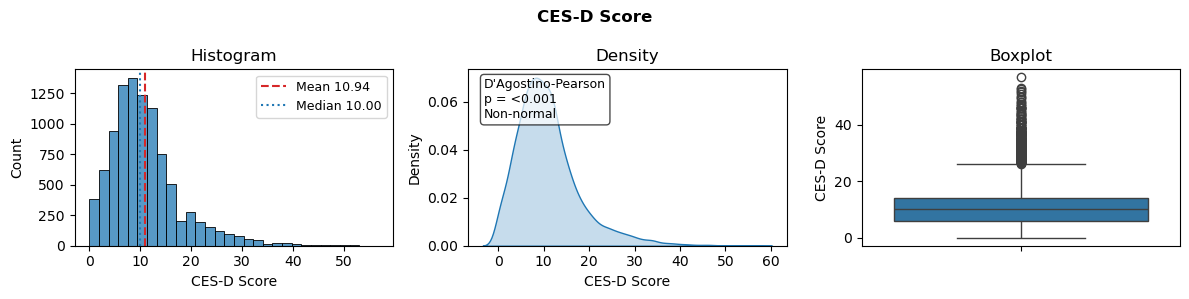

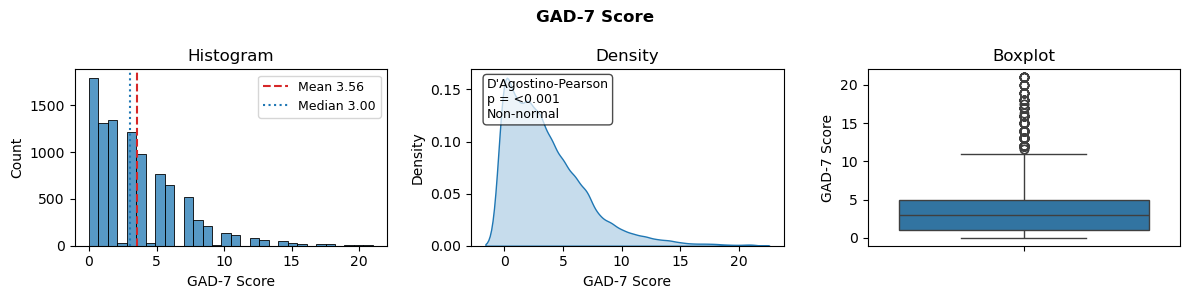

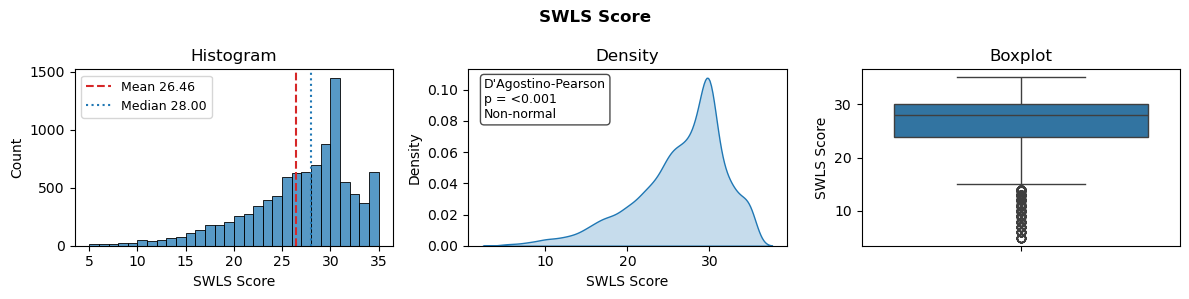

{'summary':                 n  missing_n  missing_pct    mean     sd  ci95_lower  \
 CES-D Score  9567        433         4.33  10.944  7.075      10.803   
 GAD-7 Score  9726        274         2.74   3.561  3.373       3.494   
 SWLS Score   9748        252         2.52  26.463  5.549      26.353   
 
              ci95_upper  min     Q1  median    Q3     max   IQR  mode  \
 CES-D Score      11.086  0.0   6.00    10.0  14.0  56.842  8.00   9.0   
 GAD-7 Score       3.628  0.0   1.00     3.0   5.0  21.000  4.00   0.0   
 SWLS Score       26.573  5.0  23.75    28.0  30.0  35.000  6.25  30.0   
 
              skewness  kurtosis  
 CES-D Score     1.451     3.482  
 GAD-7 Score     1.473     2.979  
 SWLS Score     -0.960     0.818  ,
 'normality':                 n                test  statistic  p_value  normal
 column                                                           
 CES-D Score  9567  D'Agostino-Pearson  2689.2093      0.0   False
 GAD-7 Score  9726  D'Agostino-Pearson  26

In [6]:
univar.univar_analysis(data, cols.mental_numeric, variable_type='numeric')

In [7]:
univar.summarize_numeric(data, cols.mental_numeric)

,n,missing_n,missing_pct,mean,sd,ci95_lower,ci95_upper,min,Q1,median,Q3,max,IQR,mode,skewness,kurtosis
CES-D Score,9567,433,4.33,10.944,7.075,10.803,11.086,0.0,6.00,10.0,14.0,56.842,8.00,9.0,1.451,3.482
GAD-7 Score,9726,274,2.74,3.561,3.373,3.494,3.628,0.0,1.00,3.0,5.0,21.000,4.00,0.0,1.473,2.979
SWLS Score,9748,252,2.52,26.463,5.549,26.353,26.573,5.0,23.75,28.0,30.0,35.000,6.25,30.0,-0.960,0.818


## Green Exposure – NDVI

── Missing Values ──────────────────────────
                     missing_n  missing_pct  present_n
NDVI (100m Buffer)         432         4.32       9568
NDVI (200m Buffer)         432         4.32       9568
NDVI (500m Buffer)         432         4.32       9568
NDVI (1000m Buffer)        432         4.32       9568

── Descriptive Statistics ───────────────────
                        n  missing_n  missing_pct   mean     sd  ci95_lower  ci95_upper    min     Q1  median     Q3    max    IQR   mode  skewness  kurtosis
NDVI (100m Buffer)   9568        432         4.32  0.475  0.085       0.473       0.476  0.134  0.415   0.481  0.539  0.767  0.124  0.540    -0.232    -0.216
NDVI (200m Buffer)   9568        432         4.32  0.485  0.081       0.483       0.486  0.169  0.427   0.491  0.544  0.765  0.117  0.347    -0.231    -0.180
NDVI (500m Buffer)   9568        432         4.32  0.503  0.077       0.501       0.504  0.217  0.450   0.510  0.556  0.786  0.106  0.272    -0.292    -0.024
N

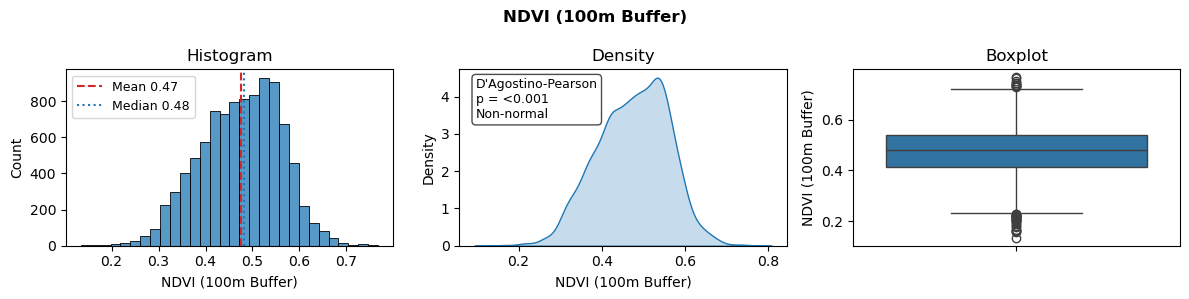

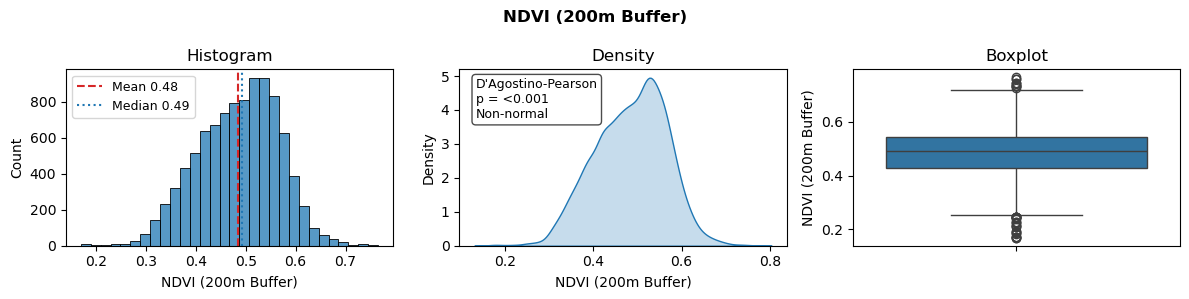

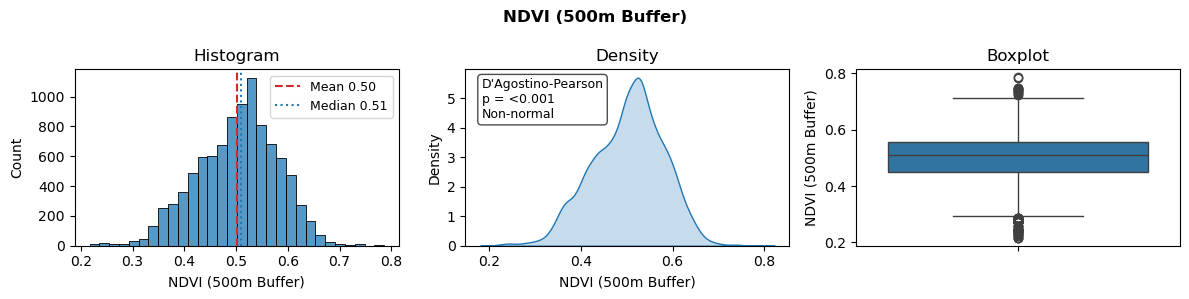

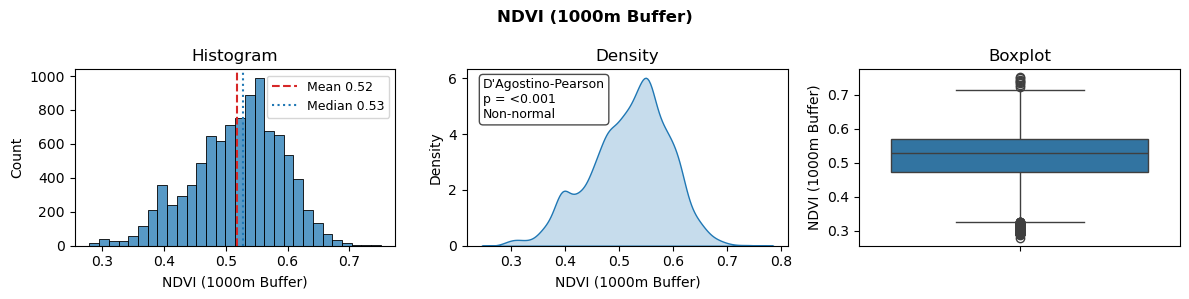

{'summary':                         n  missing_n  missing_pct   mean     sd  ci95_lower  \
 NDVI (100m Buffer)   9568        432         4.32  0.475  0.085       0.473   
 NDVI (200m Buffer)   9568        432         4.32  0.485  0.081       0.483   
 NDVI (500m Buffer)   9568        432         4.32  0.503  0.077       0.501   
 NDVI (1000m Buffer)  9568        432         4.32  0.519  0.073       0.517   
 
                      ci95_upper    min     Q1  median     Q3    max    IQR  \
 NDVI (100m Buffer)        0.476  0.134  0.415   0.481  0.539  0.767  0.124   
 NDVI (200m Buffer)        0.486  0.169  0.427   0.491  0.544  0.765  0.117   
 NDVI (500m Buffer)        0.504  0.217  0.450   0.510  0.556  0.786  0.106   
 NDVI (1000m Buffer)       0.520  0.280  0.472   0.528  0.570  0.751  0.098   
 
                       mode  skewness  kurtosis  
 NDVI (100m Buffer)   0.540    -0.232    -0.216  
 NDVI (200m Buffer)   0.347    -0.231    -0.180  
 NDVI (500m Buffer)   0.272    -0.292   

In [8]:
univar.univar_analysis(data, cols.ndvi, variable_type='numeric')

In [9]:
univar.summarize_numeric(data, cols.ndvi)

,n,missing_n,missing_pct,mean,sd,ci95_lower,ci95_upper,min,Q1,median,Q3,max,IQR,mode,skewness,kurtosis
NDVI (100m Buffer),9568,432,4.32,0.475,0.085,0.473,0.476,0.134,0.415,0.481,0.539,0.767,0.124,0.540,-0.232,-0.216
NDVI (200m Buffer),9568,432,4.32,0.485,0.081,0.483,0.486,0.169,0.427,0.491,0.544,0.765,0.117,0.347,-0.231,-0.180
NDVI (500m Buffer),9568,432,4.32,0.503,0.077,0.501,0.504,0.217,0.450,0.510,0.556,0.786,0.106,0.272,-0.292,-0.024
NDVI (1000m Buffer),9568,432,4.32,0.519,0.073,0.517,0.520,0.280,0.472,0.528,0.570,0.751,0.098,0.289,-0.386,-0.111


## Green Exposure – Land-use-based

── Missing Values ──────────────────────────
            missing_n  missing_pct  present_n
green_100         472         4.72       9528
green_200         472         4.72       9528
green_500         472         4.72       9528
green_1000        472         4.72       9528

── Descriptive Statistics ───────────────────
               n  missing_n  missing_pct         mean           sd   ci95_lower   ci95_upper         min           Q1      median           Q3          max          IQR       mode  skewness  kurtosis
green_100   9528        472         4.72    85658.463   401048.052    77605.724    93711.202     999.720    18188.100    26085.78    40210.735   9770998.84    22022.635   12503.52    16.632   340.646
green_200   9528        472         4.72   221870.551   544859.345   210930.191   232810.911    6912.000    68041.620    94827.95   180710.215  10430960.84   112668.595   41646.96    10.991   162.925
green_500   9528        472         4.72   836577.939   775837.887   820999.70

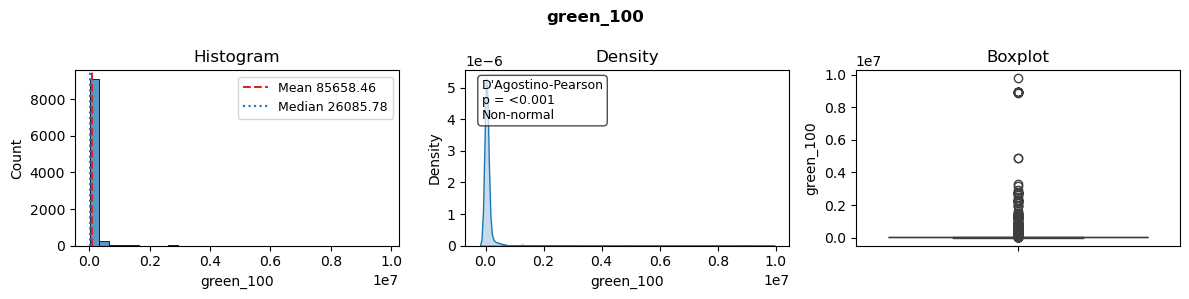

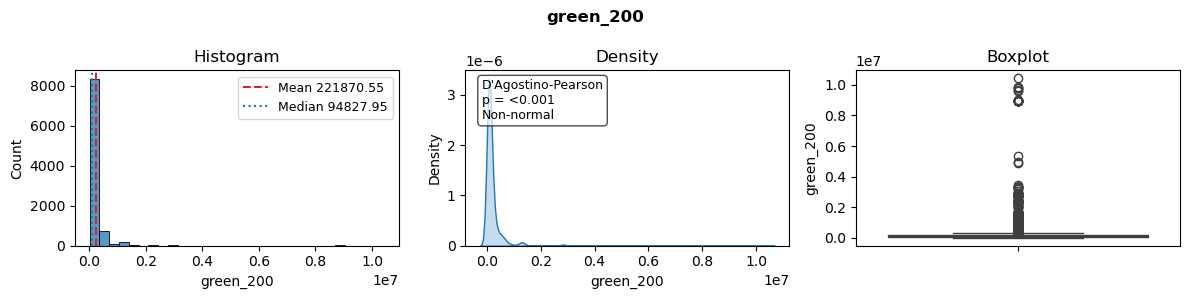

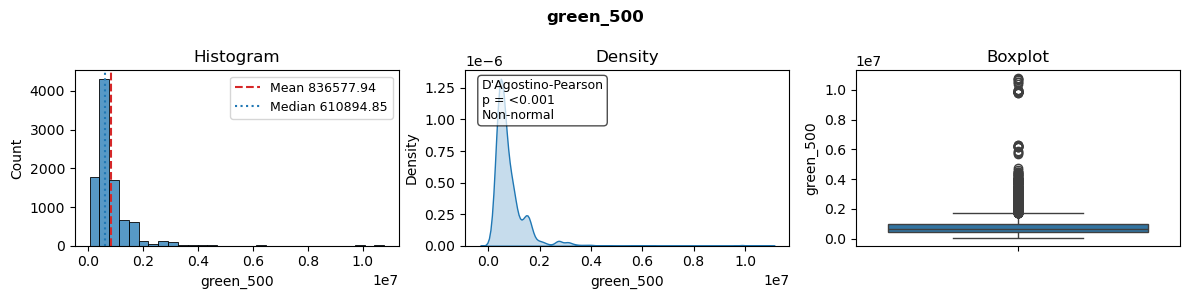

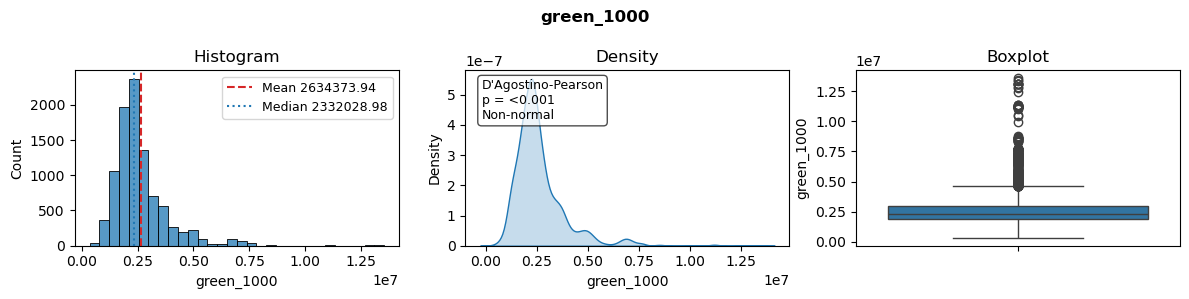

{'summary':                n  missing_n  missing_pct         mean           sd  \
 green_100   9528        472         4.72    85658.463   401048.052   
 green_200   9528        472         4.72   221870.551   544859.345   
 green_500   9528        472         4.72   836577.939   775837.887   
 green_1000  9528        472         4.72  2634373.943  1283580.863   
 
              ci95_lower   ci95_upper         min           Q1      median  \
 green_100     77605.724    93711.202     999.720    18188.100    26085.78   
 green_200    210930.191   232810.911    6912.000    68041.620    94827.95   
 green_500    820999.706   852156.172   51277.380   450286.935   610894.85   
 green_1000  2608600.618  2660147.268  342190.288  1874915.305  2332028.98   
 
                      Q3          max          IQR       mode  skewness  \
 green_100     40210.735   9770998.84    22022.635   12503.52    16.632   
 green_200    180710.215  10430960.84   112668.595   41646.96    10.991   
 green_500    9

In [10]:
univar.univar_analysis(data, cols.greenspace_raw, variable_type='numeric')

In [11]:
univar.summarize_numeric(data, cols.greenspace_raw)

,n,missing_n,missing_pct,mean,sd,ci95_lower,ci95_upper,min,Q1,median,Q3,max,IQR,mode,skewness,kurtosis
green_100,9528,472,4.72,85658.463,401048.052,77605.724,93711.202,999.720,18188.100,26085.78,40210.735,9770998.84,22022.635,12503.52,16.632,340.646
green_200,9528,472,4.72,221870.551,544859.345,210930.191,232810.911,6912.000,68041.620,94827.95,180710.215,10430960.84,112668.595,41646.96,10.991,162.925
green_500,9528,472,4.72,836577.939,775837.887,820999.706,852156.172,51277.380,450286.935,610894.85,959150.420,10784641.92,508863.485,153690.84,5.869,56.856
green_1000,9528,472,4.72,2634373.943,1283580.863,2608600.618,2660147.268,342190.288,1874915.305,2332028.98,2970805.080,13555697.88,1095889.775,682217.64,2.552,11.182


## Age distribution

── Descriptive Statistics ───────────────────
         n  missing_n  missing_pct    mean      sd  ci95_lower  ci95_upper    min      Q1  median      Q3    max     IQR   mode  skewness  kurtosis
Age  10000          0          0.0  57.469  12.479      57.224      57.713  18.24  47.678   57.94  68.242  80.94  20.565  47.21    -0.311    -0.481

── Normality Tests ──────────────────────────
            n                test  statistic  p_value  normal
column                                                       
Age     10000  D'Agostino-Pearson   326.9559      0.0   False



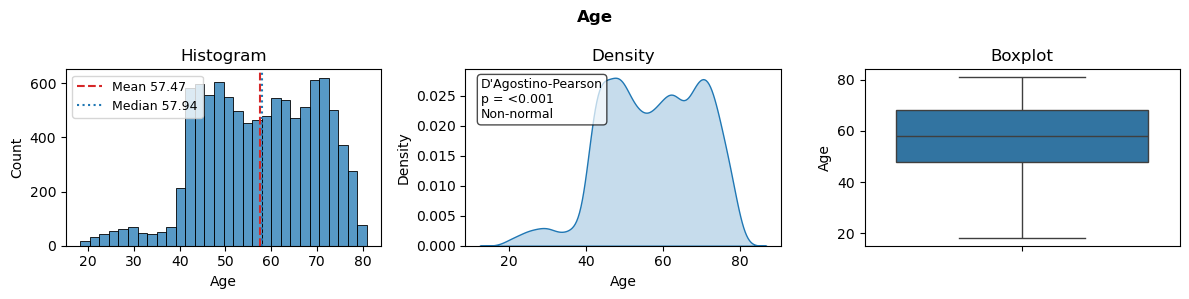

{'summary':          n  missing_n  missing_pct    mean      sd  ci95_lower  ci95_upper  \
 Age  10000          0          0.0  57.469  12.479      57.224      57.713   
 
        min      Q1  median      Q3    max     IQR   mode  skewness  kurtosis  
 Age  18.24  47.678   57.94  68.242  80.94  20.565  47.21    -0.311    -0.481  ,
 'normality':             n                test  statistic  p_value  normal
 column                                                       
 Age     10000  D'Agostino-Pearson   326.9559      0.0   False}

In [12]:
univar.univar_analysis(data, cols.age, variable_type='numeric')

In [13]:
univar.summarize_numeric(data, cols.age)

,n,missing_n,missing_pct,mean,sd,ci95_lower,ci95_upper,min,Q1,median,Q3,max,IQR,mode,skewness,kurtosis
Age,10000,0,0.0,57.469,12.479,57.224,57.713,18.24,47.678,57.94,68.242,80.94,20.565,47.21,-0.311,-0.481


# Bivariate Analysis

## Sumary of mental scores (numeric) over sociodemographics (categorical)


  CES-D Score  ×  Sex
  method: Kruskal-Wallis
  statistic: 104.82165579025992
  p_value: 1.3363877561446008e-24
  n: 9567
  effect_size: 0.010957731109163697
  effect_label: eta²_H (Kruskal-Wallis effect size)

group_stats:
   Sex     n       mean        sd     median  q25   q75  IQR
0    0  4613  10.050381  6.170527   9.000000  6.0  13.0  7.0
1    1  4954  11.776994  7.731814  10.526316  6.0  15.0  9.0


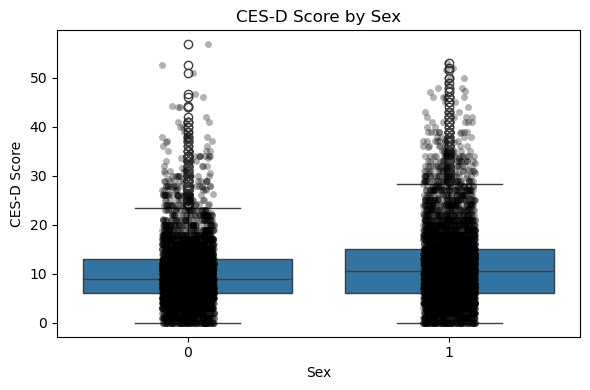


  GAD-7 Score  ×  Sex
  method: Kruskal-Wallis
  statistic: 280.9222165251882
  p_value: 4.727486966329934e-63
  n: 9726
  effect_size: 0.0288866032416646
  effect_label: eta²_H (Kruskal-Wallis effect size)

group_stats:
   Sex     n      mean        sd  median  q25  q75  IQR
0    0  4618  3.004403  3.110023     2.0  1.0  4.0  3.0
1    1  5108  4.064311  3.520376     3.0  1.0  6.0  5.0


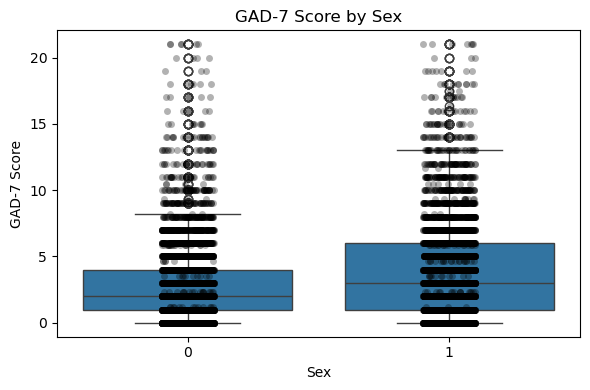


  SWLS Score  ×  Sex
  method: Kruskal-Wallis
  statistic: 4.590910491366118
  p_value: 0.03214193560580604
  n: 9748
  effect_size: 0.00047100753989598004
  effect_label: eta²_H (Kruskal-Wallis effect size)

group_stats:
   Sex     n       mean        sd  median   q25   q75  IQR
0    0  4633  26.358947  5.548571    28.0  24.0  30.0  6.0
1    1  5115  26.556794  5.549130    28.0  23.0  30.0  7.0


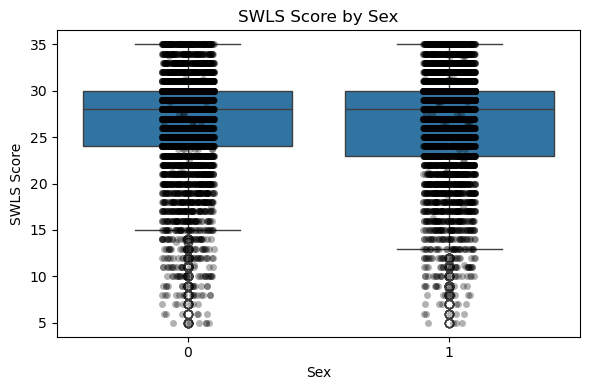

{('CES-D Score',
  'Sex'): {'results': {'method': 'Kruskal-Wallis',
   'statistic': np.float64(104.82165579025992),
   'p_value': np.float64(1.3363877561446008e-24),
   'n': 9567,
   'effect_size': np.float64(0.010957731109163697),
   'effect_label': 'eta²_H (Kruskal-Wallis effect size)',
   'group_stats':    Sex     n       mean        sd     median  q25   q75  IQR
   0    0  4613  10.050381  6.170527   9.000000  6.0  13.0  7.0
   1    1  4954  11.776994  7.731814  10.526316  6.0  15.0  9.0}, 'fig': <Figure size 600x400 with 1 Axes>},
 ('GAD-7 Score',
  'Sex'): {'results': {'method': 'Kruskal-Wallis',
   'statistic': np.float64(280.9222165251882),
   'p_value': np.float64(4.727486966329934e-63),
   'n': 9726,
   'effect_size': np.float64(0.0288866032416646),
   'effect_label': 'eta²_H (Kruskal-Wallis effect size)',
   'group_stats':    Sex     n      mean        sd  median  q25  q75  IQR
   0    0  4618  3.004403  3.110023     2.0  1.0  4.0  3.0
   1    1  5108  4.064311  3.520376    

In [14]:
x_data = cols.mental_numeric
y_data = ['Sex'] #, 'Age_group', 'Socioeconomic Status (Tiers)']
bivar.bivar_analysis(data, x_data=x_data, y_data=y_data, x_type='numeric', y_type="categorical")

## Distribution of a single mental score over one variable (age groups)

In [15]:
outcome = 'CES-D Score'
predictor = 'Age_group'
bivar.pairwise_stats(data,
                     outcome_cols = outcome,
                     predictor_cols = predictor,
                     )[outcome, predictor]["group_stats"]#["mann_whitney"]

[1/1] Processing... CES-D Score × Age_group
   n=9567 | Non-normal | Recommended: kruskal_wallis | p = 0.0
------------------------------------------------------------


,Age_group,n,mean,sd,median,q25,q75,min,max,IQR
0,"[18, 40)",507,9.845,7.194,8.000,5.000,12.000,0.0,49.000,7.000
1,"[40, 53)",3309,10.619,7.473,9.000,6.000,13.333,0.0,50.000,7.333
2,"[53, 65)",2735,11.354,7.327,10.000,6.316,14.000,0.0,56.842,7.684
3,"[65, 81)",3016,11.116,6.299,10.794,7.000,14.000,0.0,50.000,7.000


In [16]:
# Single pair
result = bivar.group_differences(data, "CES-D Score", "Sex")
result["recommended_test"]          # e.g. "mann_whitney"
result["tests"]["mann_whitney"]     # {"statistic": ..., "p_value": ...}
result["normality"]                 # per-group Shapiro-Wilk DataFrame
#result["group_stats"]               # per-group descriptives DataFrame

   n=9567 | Non-normal | Recommended: mann_whitney | p = 0.0


,n,test,statistic,p_value,normal
group,,,,,
1,4954,Shapiro-Wilk,0.9165,0.0,False
0,4613,Shapiro-Wilk,0.9029,0.0,False


## Distribution of multiple mental scores over sociodemographics

In [17]:
#outcome = 'CES-D Score'
predictor = ['Sex', 'Age_group', 'Socioeconomic Status (Tiers)']
pair_results = bivar.pairwise_stats(data,
                     outcome_cols = cols.mental_numeric,
                     predictor_cols = predictor,
                     )#[outcome, predictor]["group_stats"]#["mann_whitney"]

[1/9] Processing... CES-D Score × Sex
   n=9567 | Non-normal | Recommended: mann_whitney | p = 0.0
------------------------------------------------------------
[2/9] Processing... CES-D Score × Age_group
   n=9567 | Non-normal | Recommended: kruskal_wallis | p = 0.0
------------------------------------------------------------
[3/9] Processing... CES-D Score × Socioeconomic Status (Tiers)

[Warning] N = 5744 > 5000: Shapiro-Wilk may be inaccurate, D'Agostino-Pearson test used instead
   n=9539 | Non-normal | Recommended: kruskal_wallis | p = 0.0
------------------------------------------------------------
[4/9] Processing... GAD-7 Score × Sex

[Warning] N = 5108 > 5000: Shapiro-Wilk may be inaccurate, D'Agostino-Pearson test used instead
   n=9726 | Non-normal | Recommended: mann_whitney | p = 0.0
------------------------------------------------------------
[5/9] Processing... GAD-7 Score × Age_group
   n=9726 | Non-normal | Recommended: kruskal_wallis | p = 0.0
------------------------

In [18]:
for pair, res in pair_results.items():
    print(f"\n SUMMARY: {pair[0]} & {pair[1]} ---")
    print(f"\t {res['summary']}")
    #print(res["group_stats"].to_string(index=False))
    display(res["group_stats"])
    print("-"*60)


 SUMMARY: CES-D Score & Sex ---
	  n=9567 | Non-normal | Recommended: mann_whitney | p = 0.0


,Sex,n,mean,sd,median,q25,q75,min,max,IQR
0,0,4613,10.050,6.171,9.000,6.0,13.0,0.0,56.842,7.0
1,1,4954,11.777,7.732,10.526,6.0,15.0,0.0,53.000,9.0


------------------------------------------------------------

 SUMMARY: CES-D Score & Age_group ---
	  n=9567 | Non-normal | Recommended: kruskal_wallis | p = 0.0


,Age_group,n,mean,sd,median,q25,q75,min,max,IQR
0,"[18, 40)",507,9.845,7.194,8.000,5.000,12.000,0.0,49.000,7.000
1,"[40, 53)",3309,10.619,7.473,9.000,6.000,13.333,0.0,50.000,7.333
2,"[53, 65)",2735,11.354,7.327,10.000,6.316,14.000,0.0,56.842,7.684
3,"[65, 81)",3016,11.116,6.299,10.794,7.000,14.000,0.0,50.000,7.000


------------------------------------------------------------

 SUMMARY: CES-D Score & Socioeconomic Status (Tiers) ---
	  n=9539 | Non-normal | Recommended: kruskal_wallis | p = 0.0


...

------------------------------------------------------------

 SUMMARY: SWLS Score & Age_group ---
	  n=9748 | Non-normal | Recommended: kruskal_wallis | p = 0.0


,Age_group,n,mean,sd,median,q25,q75,min,max,IQR
0,"[18, 40)",511,26.641,5.310,28.0,24.0,30.0,8.0,35.0,6.0
1,"[40, 53)",3348,25.947,5.849,27.0,23.0,30.0,5.0,35.0,7.0
2,"[53, 65)",2802,26.059,5.714,27.0,23.0,30.0,5.0,35.0,7.0
3,"[65, 81)",3087,27.358,4.963,29.0,25.0,30.0,5.0,35.0,5.0


------------------------------------------------------------

 SUMMARY: SWLS Score & Socioeconomic Status (Tiers) ---
	  n=9719 | Non-normal | Recommended: kruskal_wallis | p = 0.0


,Socioeconomic Status (Tiers),n,mean,sd,median,q25,q75,min,max,IQR
0,1.0,1902,23.961,6.535,25.0,19.0,29.0,5.0,35.0,10.0
1,2.0,5857,26.724,5.206,28.0,24.0,30.0,5.0,35.0,6.0
2,3.0,1960,28.100,4.643,29.0,26.0,31.0,6.0,35.0,5.0


------------------------------------------------------------


## Summary table of binary descriptive

In [19]:
stats_cols = ["n", "mean", "sd"]

rows = []
for (X, Y), res in pair_results.items():
    stats = res["group_stats"]
    stats = stats[[col for col in stats_cols if col in res["group_stats"].columns]].copy()
    stats.insert(0, "X", X)
    stats.insert(1, "Y", Y)
    rows.append(stats)

if not rows:
    print("No results to display.")
else:
    summary = pd.concat(rows, axis=0, ignore_index=True)

    pair_n   = summary.groupby(["X", "Y"])["n"].transform("sum")
    n_idx    = summary.columns.get_loc("n")
    summary.insert(n_idx + 1, "n_pct", (summary["n"] / pair_n * 100).round(2))

    print("\n── Group Summary ──────────────────────────────────────────")
    display(summary.round(2))


── Group Summary ──────────────────────────────────────────


,X,Y,n,n_pct,mean,sd
0,CES-D Score,Sex,4613,48.22,10.05,6.17
1,CES-D Score,Sex,4954,51.78,11.78,7.73
2,CES-D Score,Age_group,507,5.30,9.85,7.19
3,CES-D Score,Age_group,3309,34.59,10.62,7.47
4,CES-D Score,Age_group,2735,28.59,11.35,7.33
5,CES-D Score,Age_group,3016,31.53,11.12,6.30
6,CES-D Score,Socioeconomic Status (Tiers),1863,19.53,13.81,7.99
7,CES-D Score,Socioeconomic Status (Tiers),5744,60.22,10.84,6.68
8,CES-D Score,Socioeconomic Status (Tiers),1932,20.25,8.50,6.24
9,GAD-7 Score,Sex,4618,47.48,3.00,3.11


## total number of mental scores and their mean (sd)

In [21]:
pd.DataFrame([data[cols.mental_numeric].count(), data[cols.mental_numeric].mean(), data[cols.mental_numeric].std()],
             index=["N", "mean", "sd"],
             ).T.round(2)


,N,mean,sd
CES-D Score,9567.0,10.94,7.07
GAD-7 Score,9726.0,3.56,3.37
SWLS Score,9748.0,26.46,5.55


## Distribution of multiple greenness exposure over sociodemographics

In [22]:
#outcome = 'CES-D Score'
predictor = ['Socioeconomic Status (Tiers)'] #'Sex', 'Age_group', 
pair_results = bivar.pairwise_stats(data,
                     outcome_cols = cols.ndvi + cols.greenspace_raw,
                     predictor_cols = predictor,
                     )#[outcome, predictor]["group_stats"]#["mann_whitney"]

[1/8] Processing... NDVI (100m Buffer) × Socioeconomic Status (Tiers)

[Warning] N = 5724 > 5000: Shapiro-Wilk may be inaccurate, D'Agostino-Pearson test used instead
   n=9535 | Non-normal | Recommended: kruskal_wallis | p = 0.0
------------------------------------------------------------
[2/8] Processing... NDVI (200m Buffer) × Socioeconomic Status (Tiers)

[Warning] N = 5724 > 5000: Shapiro-Wilk may be inaccurate, D'Agostino-Pearson test used instead
   n=9535 | Non-normal | Recommended: kruskal_wallis | p = 0.0
------------------------------------------------------------
[3/8] Processing... NDVI (500m Buffer) × Socioeconomic Status (Tiers)

[Warning] N = 5724 > 5000: Shapiro-Wilk may be inaccurate, D'Agostino-Pearson test used instead
   n=9535 | Non-normal | Recommended: kruskal_wallis | p = 0.0
------------------------------------------------------------
[4/8] Processing... NDVI (1000m Buffer) × Socioeconomic Status (Tiers)

[Warning] N = 5724 > 5000: Shapiro-Wilk may be inaccura

In [23]:
for pair, res in pair_results.items():
    print(f"\n SUMMARY: {pair[0]} & {pair[1]} ---")
    print(f"\t {res['summary']}")
    #print(res["group_stats"].to_string(index=False))
    display(res["group_stats"])
    print("-"*60)


 SUMMARY: NDVI (100m Buffer) & Socioeconomic Status (Tiers) ---
	  n=9535 | Non-normal | Recommended: kruskal_wallis | p = 0.0


,Socioeconomic Status (Tiers),n,mean,sd,median,q25,q75,min,max,IQR
0,1.0,1927,0.469,0.086,0.476,0.408,0.535,0.134,0.738,0.127
1,2.0,5724,0.478,0.083,0.485,0.420,0.540,0.160,0.753,0.119
2,3.0,1884,0.470,0.091,0.472,0.405,0.539,0.183,0.767,0.134


------------------------------------------------------------

 SUMMARY: NDVI (200m Buffer) & Socioeconomic Status (Tiers) ---
	  n=9535 | Non-normal | Recommended: kruskal_wallis | p = 0.0


,Socioeconomic Status (Tiers),n,mean,sd,median,q25,q75,min,max,IQR
0,1.0,1927,0.477,0.081,0.483,0.420,0.536,0.169,0.765,0.116
1,2.0,5724,0.488,0.079,0.495,0.434,0.546,0.169,0.745,0.112
2,3.0,1884,0.482,0.087,0.489,0.415,0.548,0.186,0.740,0.133


------------------------------------------------------------

 SUMMARY: NDVI (500m Buffer) & Socioeconomic Status (Tiers) ---
	  n=9535 | Non-normal | Recommended: kruskal_wallis | p = 0.0


...

------------------------------------------------------------

 SUMMARY: green_500 & Socioeconomic Status (Tiers) ---
	  n=9495 | Non-normal | Recommended: kruskal_wallis | p = 0.0


,Socioeconomic Status (Tiers),n,mean,sd,median,q25,q75,min,max,IQR
0,1.0,1916,748759.808,741997.839,565947.37,438116.465,806766.190,105183.360,10656471.40,368649.725
1,2.0,5697,837524.244,755104.880,615964.36,454855.840,961988.581,51277.380,10784641.92,507132.741
2,3.0,1882,923490.034,861180.284,683510.94,460543.000,1145398.170,53134.255,10534893.56,684855.170


------------------------------------------------------------

 SUMMARY: green_1000 & Socioeconomic Status (Tiers) ---
	  n=9495 | Non-normal | Recommended: kruskal_wallis | p = 0.0


,Socioeconomic Status (Tiers),n,mean,sd,median,q25,q75,min,max,IQR
0,1.0,1916,2516367.970,1242965.664,2254677.39,1826432.39,2782486.070,682217.640,13125053.58,956053.680
1,2.0,5697,2657889.043,1294821.906,2347753.30,1889944.02,3013860.840,342190.288,13555697.88,1123916.820
2,3.0,1882,2680874.663,1283334.792,2379635.25,1912833.70,3052162.001,413549.047,11239977.44,1139328.301


------------------------------------------------------------


## Summary table of binary descriptive – greenness exposure

In [24]:
stats_cols = ["Socioeconomic Status (Tiers)", "n", "median", "IQR"]

rows = []
for (X, Y), res in pair_results.items():
    stats = res["group_stats"]
    stats = stats[[col for col in stats_cols if col in res["group_stats"].columns]].copy()
    stats.insert(0, "X", X)
    stats.insert(1, "Y", Y)
    rows.append(stats)

if not rows:
    print("No results to display.")
else:
    summary = pd.concat(rows, axis=0, ignore_index=True)

    pair_n   = summary.groupby(["X", "Y"])["n"].transform("sum")
    n_idx    = summary.columns.get_loc("n")
    summary.insert(n_idx + 1, "n_pct", (summary["n"] / pair_n * 100).round(2))
    summary.insert(n_idx + 1, "n_total", (pair_n).round(2))
    summary["radius"] = summary["X"].str.extract(r"(\d+)").astype(int)#[0]
    summary["median_pct"] = summary["median"]
    summary["IQR_pct"]    = summary["IQR"]
    summary.loc[summary["X"].isin(cols.greenspace_raw),"median_pct"] = summary["median"] / (np.pi * (summary["radius"] ** 2)) * 100
    summary.loc[summary["X"].isin(cols.greenspace_raw),"IQR_pct"]    = summary["IQR"] / (np.pi * (summary["radius"] ** 2)) * 100
    
    summary.loc[summary["X"].isin(cols.greenspace_raw), "median"] /= 10000
    summary.loc[summary["X"].isin(cols.greenspace_raw), "IQR"] /= 10000
    
    print("\n── Group Summary ──────────────────────────────────────────")
    display(summary.round(2))


── Group Summary ──────────────────────────────────────────


,X,Y,Socioeconomic Status (Tiers),n,n_total,n_pct,median,IQR,radius,median_pct,IQR_pct
0,NDVI (100m Buffer),Socioeconomic Status (Tiers),1.0,1927,9535,20.21,0.48,0.13,100,0.48,0.13
1,NDVI (100m Buffer),Socioeconomic Status (Tiers),2.0,5724,9535,60.03,0.48,0.12,100,0.48,0.12
2,NDVI (100m Buffer),Socioeconomic Status (Tiers),3.0,1884,9535,19.76,0.47,0.13,100,0.47,0.13
3,NDVI (200m Buffer),Socioeconomic Status (Tiers),1.0,1927,9535,20.21,0.48,0.12,200,0.48,0.12
4,NDVI (200m Buffer),Socioeconomic Status (Tiers),2.0,5724,9535,60.03,0.50,0.11,200,0.50,0.11
5,NDVI (200m Buffer),Socioeconomic Status (Tiers),3.0,1884,9535,19.76,0.49,0.13,200,0.49,0.13
6,NDVI (500m Buffer),Socioeconomic Status (Tiers),1.0,1927,9535,20.21,0.50,0.10,500,0.50,0.10
7,NDVI (500m Buffer),Socioeconomic Status (Tiers),2.0,5724,9535,60.03,0.51,0.10,500,0.51,0.10
8,NDVI (500m Buffer),Socioeconomic Status (Tiers),3.0,1884,9535,19.76,0.51,0.12,500,0.51,0.12
9,NDVI (1000m Buffer),Socioeconomic Status (Tiers),1.0,1927,9535,20.21,0.52,0.09,1000,0.52,0.09


## total number of mental scores and their mean (sd)

In [25]:
q1 = data[cols.ndvi].quantile(0.25)
q3 = data[cols.ndvi].quantile(0.75)
pd.DataFrame([data[cols.ndvi].count(), data[cols.ndvi].median(), q3-q1],
             index=["N", "median", "IQR"],
             ).T.round(2)


,N,median,IQR
NDVI (100m Buffer),9568.0,0.48,0.12
NDVI (200m Buffer),9568.0,0.49,0.12
NDVI (500m Buffer),9568.0,0.51,0.11
NDVI (1000m Buffer),9568.0,0.53,0.10


In [26]:
q1 = data[cols.greenspace_raw].quantile(0.25)
q3 = data[cols.greenspace_raw].quantile(0.75)
df_tmp = pd.DataFrame([data[cols.greenspace_raw].count(), data[cols.greenspace_raw].median(), (q3-q1)],
                      index=["N", "median", "IQR"],
                      ).T.round(2)
df_tmp.insert(0, "radius", df_tmp.index.astype(str).str.extract(r"(\d+)").astype(int).values)

df_tmp["median_pct"] = df_tmp["median"] / (np.pi * (df_tmp["radius"] ** 2)) * 100
df_tmp["IQR_pct"]    = df_tmp["IQR"] / (np.pi * (df_tmp["radius"] ** 2)) * 100

df_tmp["median"] /= 1e4
df_tmp["IQR"]    /= 1e4

df_tmp.round(2)

,radius,N,median,IQR,median_pct,IQR_pct
green_100,100,9528.0,2.61,2.20,83.03,70.10
green_200,200,9528.0,9.48,11.27,75.46,89.66
green_500,500,9528.0,61.09,50.89,77.78,64.79
green_1000,1000,9528.0,233.20,109.59,74.23,34.88


## Bivariate ordinal outcome – single variable

In [27]:
outcome = cols.mental_ordinal[2]
predictor = cols.greenspace_quartiles[0]
res = bivar.analyze_ordinal_outcome(data, outcome, predictor)

In [28]:
res['summary_df']#.loc['chi2'].values[0]

,0
outcome,SWLS Ordinal
predictor,Green Space Quartile (100m Buffer)
n,9283
spearman_rho,0.0903
spearman_p,0.0
kendall_tau,0.0756
kendall_p,0.0
chi2,95.4984
chi2_p,0.0
chi2_dof,18


## Bivariate categorical outcome – single variable

In [29]:
outcome = cols.mental_ordinal[1]
predictor = cols.greenspace_quartiles[1]
res = bivar.analyze_categorical_categorical(data, outcome, predictor)

In [30]:
pd.DataFrame([res]).T

,0
table,Green Space Quartile (200m Buffer) 1.0 2.0...
test,chi2
statistic,22.718227
p_value,0.006861
dof,9
cramers_v,0.028591
n,9264
small_expected,False


## Bivariate ordinal outcome – multiple variables

In [111]:
rows = {}
for outcome in cols.mental_ordinal:
    for predictor in cols.greenspace_quartiles:
        results = bivar.analyze_ordinal_outcome(data, outcome, predictor, fit_ordinal=True)

        rows[(outcome, predictor)] = results["summary_df"]
        
        # --------------------------------------------------
        # Per-pair output: header → results → figure
        # --------------------------------------------------
        print(f"\n{'='*60}")
        print(f"  {outcome}  ×  {predictor}")
        print(f"{'='*60}")

        for key, val in results.items():
            if isinstance(val, pd.DataFrame):
                print(f"\n{key}:")
                print(val.to_string())
            elif val is not None:
                print(f"  {key}: {val}")

df_ordinal = pd.concat(rows, names=["outcome", "predictor"])


  CES-D Ordinal  ×  Green Space Quartile (100m Buffer)

summary_df:
                                                          0
outcome                                       CES-D Ordinal
predictor                Green Space Quartile (100m Buffer)
n                                                      9104
spearman_rho                                        -0.0345
spearman_p                                            0.001
kendall_tau                                         -0.0313
kendall_p                                             0.001
chi2                                                12.3976
chi2_p                                               0.0537
chi2_dof                                                  6
cramers_v                                            0.0261
q1_q4_odds_ratio                                     0.6628
q1_q4_fisher_p                                       0.1332
q1_risk                                              0.0171
q4_risk                        

In [112]:
predictor = "Green Space Quartile (500m Buffer)"
rows = []
for outcome in cols.mental_ordinal:
    df_tmp = df_ordinal.xs(key=(outcome, predictor), level=["outcome", "predictor"])
    rows.append(df_tmp.squeeze())

pd.concat(rows, axis=1, keys=cols.mental_ordinal)

,CES-D Ordinal,GAD-7 Ordinal,SWLS Ordinal
outcome,CES-D Ordinal,GAD-7 Ordinal,SWLS Ordinal
predictor,Green Space Quartile (500m Buffer),Green Space Quartile (500m Buffer),Green Space Quartile (500m Buffer)
n,9104,9264,9283
spearman_rho,-0.0284,-0.0279,0.0997
spearman_p,0.0067,0.0072,0.0
kendall_tau,-0.0258,-0.0249,0.0834
kendall_p,0.0067,0.0073,0.0
chi2,13.482,9.6618,108.3605
chi2_p,0.036,0.3786,0.0
chi2_dof,6,9,18


In [110]:
predictor = "Green Space Quartile (500m Buffer)"
rows = []
for outcome in cols.mental_ordinal:
    df_tmp = df_ordinal.xs(key=(outcome, predictor), level=["outcome", "predictor"])
    rows.append(df_tmp.squeeze())

pd.concat(rows, axis=1, keys=cols.mental_ordinal)

,CES-D Ordinal,GAD-7 Ordinal,SWLS Ordinal
outcome,CES-D Ordinal,GAD-7 Ordinal,SWLS Ordinal
predictor,Green Space Quartile (500m Buffer),Green Space Quartile (500m Buffer),Green Space Quartile (500m Buffer)
n,9104,9264,9283
spearman_rho,-0.0284,-0.0279,0.0997
spearman_p,0.0067,0.0072,0.0
kendall_tau,-0.0258,-0.0249,0.0834
kendall_p,0.0067,0.0073,0.0
chi2,13.482,9.6618,108.3605
chi2_p,0.036,0.3786,0.0
chi2_dof,6,9,18


# Correlation

## Correlation between mental scores (numeric) – Spearman


  CES-D Score  ×  GAD-7 Score
  x: CES-D Score
  y: GAD-7 Score
  method: spearman
  n: 9435
  correlation: 0.5399553224750667
  p_value: 0.0
  effect_size: 0.5399553224750667
  effect_label: rho (Spearman)


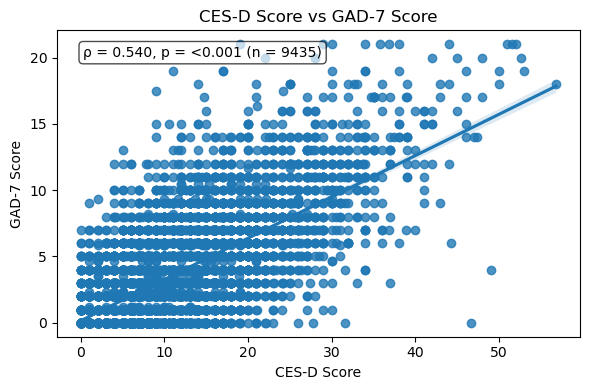


  CES-D Score  ×  SWLS Score
  x: CES-D Score
  y: SWLS Score
  method: spearman
  n: 9451
  correlation: -0.4137058883113874
  p_value: 0.0
  effect_size: -0.4137058883113874
  effect_label: rho (Spearman)


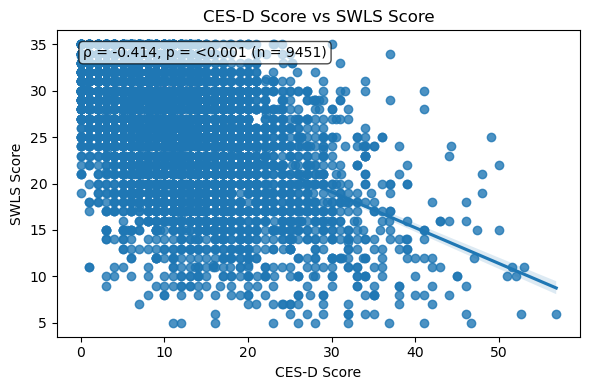


  GAD-7 Score  ×  SWLS Score
  x: GAD-7 Score
  y: SWLS Score
  method: spearman
  n: 9662
  correlation: -0.36635010548576835
  p_value: 1.10187118851683e-304
  effect_size: -0.36635010548576835
  effect_label: rho (Spearman)


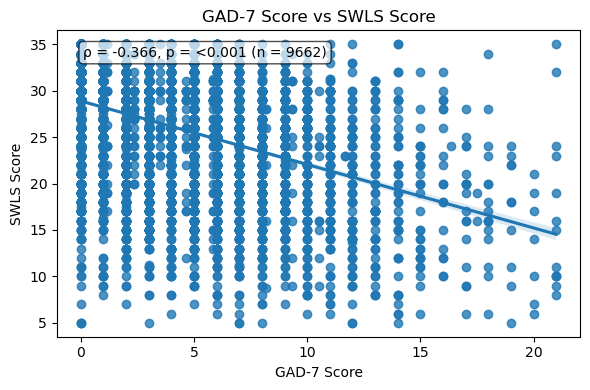

In [31]:
#x_data = 'CES-D Score'
#y_data = 'GAD-7 Score' #, 'Age_group', 'Socioeconomic Status (Tiers)']
#bivar.bivar_analysis(data, x_data=x_data, y_data=y_data, x_type='numeric', y_type="numeric");

numeric_vars = cols.mental_numeric
for ii, x_data in enumerate(numeric_vars):
    for y_data in numeric_vars[ii + 1:]:
        bivar.bivar_analysis(data, x_data=x_data, y_data=y_data, x_type="numeric", y_type="numeric");

## Correlation between mental scores (numeric) – Pearson


  CES-D Score  ×  GAD-7 Score
  x: CES-D Score
  y: GAD-7 Score
  method: pearson
  n: 9435
  correlation: 0.6520920930551624
  p_value: 0.0
  effect_size: 0.42522409782506254
  effect_label: r² (variance explained)


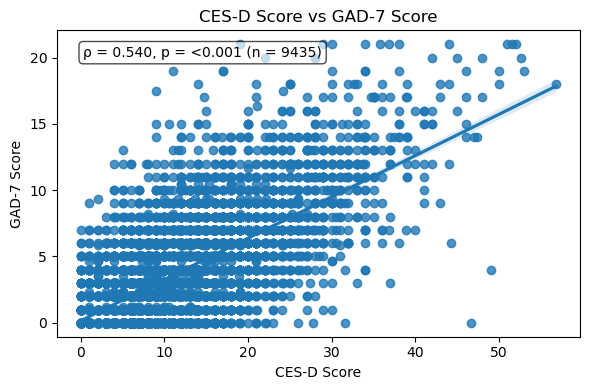


  CES-D Score  ×  SWLS Score
  x: CES-D Score
  y: SWLS Score
  method: pearson
  n: 9451
  correlation: -0.4890768543155637
  p_value: 0.0
  effect_size: 0.23919616942720712
  effect_label: r² (variance explained)


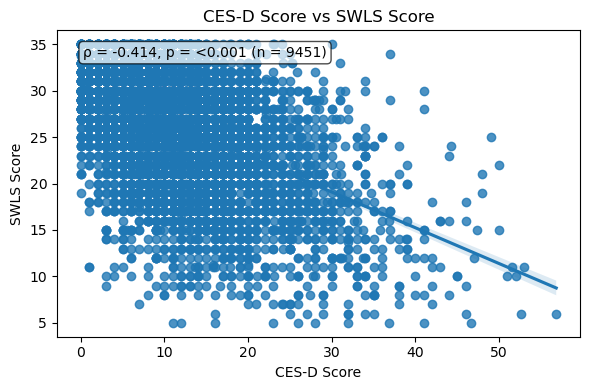


  GAD-7 Score  ×  SWLS Score
  x: GAD-7 Score
  y: SWLS Score
  method: pearson
  n: 9662
  correlation: -0.41504401854188017
  p_value: 0.0
  effect_size: 0.17226153732739258
  effect_label: r² (variance explained)


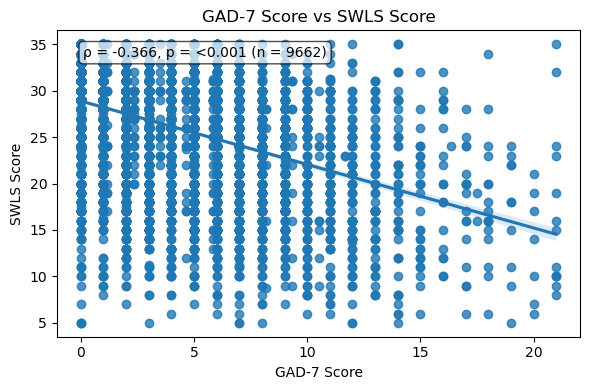

In [32]:
numeric_vars = cols.mental_numeric
for ii, x_data in enumerate(numeric_vars):
    for y_data in numeric_vars[ii + 1:]:
        results = bivar.analyze_numeric_numeric(data, x=x_data, y=y_data, method="pearson")
        bivar.plot_numeric_numeric(data, x=x_data, y=y_data);

        # --------------------------------------------------
        # Per-pair output: header → results → figure
        # --------------------------------------------------
        print(f"\n{'='*60}")
        print(f"  {x_data}  ×  {y_data}")
        print(f"{'='*60}")

        for key, val in results.items():
            if isinstance(val, pd.DataFrame):
                print(f"\n{key}:")
                print(val.to_string())
            elif val is not None:
                print(f"  {key}: {val}")

        plt.show()

## Correlation between ALL mental scores (numeric) – Spearman


  CES-D Score  ×  IDS Score
  x: CES-D Score
  y: IDS Score
  method: spearman
  n: 2789
  correlation: 0.5222695768872397
  p_value: 5.062833105185189e-195
  effect_size: 0.5222695768872397
  effect_label: rho (Spearman)


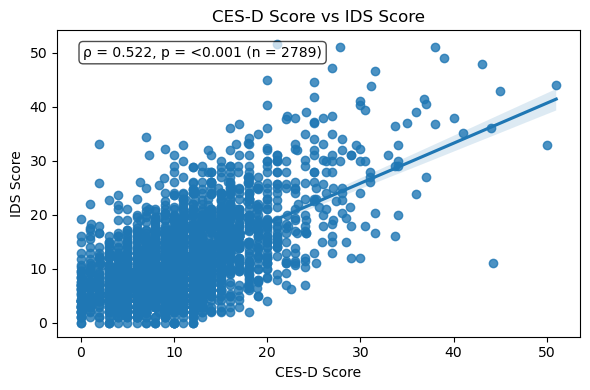


  CES-D Score  ×  GDS-15 Score
  x: CES-D Score
  y: GDS-15 Score
  method: spearman
  n: 2796
  correlation: 0.4628286787785616
  p_value: 1.8016859140913082e-148
  effect_size: 0.4628286787785616
  effect_label: rho (Spearman)


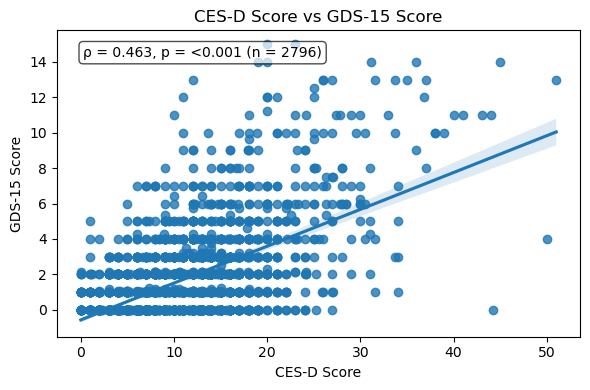


  GAD-7 Score  ×  IDS Score
  x: GAD-7 Score
  y: IDS Score
  method: spearman
  n: 2855
  correlation: 0.5496439992501151
  p_value: 3.9559237048045057e-225
  effect_size: 0.5496439992501151
  effect_label: rho (Spearman)


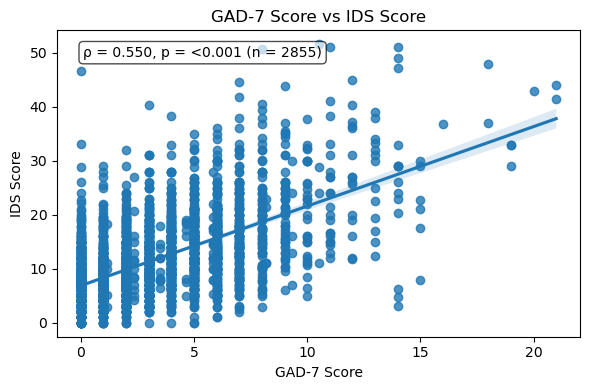


  GAD-7 Score  ×  GDS-15 Score
  x: GAD-7 Score
  y: GDS-15 Score
  method: spearman
  n: 2863
  correlation: 0.38198023851438134
  p_value: 4.0501379377442674e-100
  effect_size: 0.38198023851438134
  effect_label: rho (Spearman)


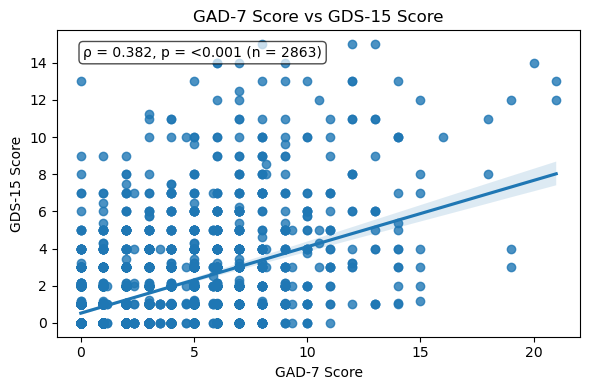


  SWLS Score  ×  IDS Score
  x: SWLS Score
  y: IDS Score
  method: spearman
  n: 2859
  correlation: -0.3736476764252675
  p_value: 2.0464545642110114e-95
  effect_size: -0.3736476764252675
  effect_label: rho (Spearman)


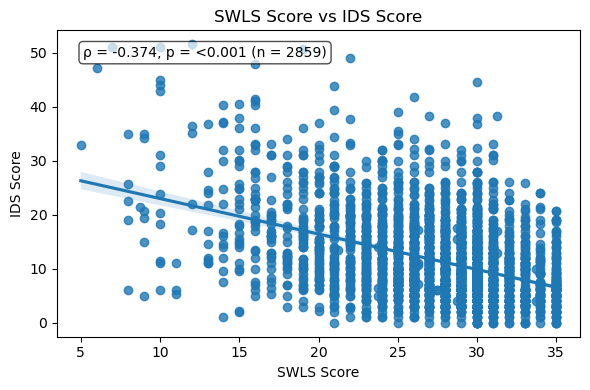


  SWLS Score  ×  GDS-15 Score
  x: SWLS Score
  y: GDS-15 Score
  method: spearman
  n: 2866
  correlation: -0.4058940934906551
  p_value: 4.0311810241521756e-114
  effect_size: -0.4058940934906551
  effect_label: rho (Spearman)


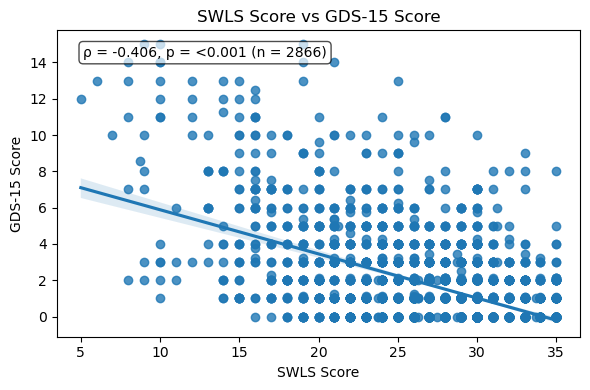

In [33]:
for x_data in cols.mental_numeric:
    for y_data in cols.mental_numeric_2:
        bivar.bivar_analysis(data, x_data=x_data, y_data=y_data, x_type="numeric", y_type="numeric");

## Correlation between ALL mental scores (numeric) – Pearson


  CES-D Score  ×  IDS Score
  x: CES-D Score
  y: IDS Score
  method: pearson
  n: 2789
  correlation: 0.6129130077188205
  p_value: 2.0360062343519722e-287
  effect_size: 0.37566235503093093
  effect_label: r² (variance explained)


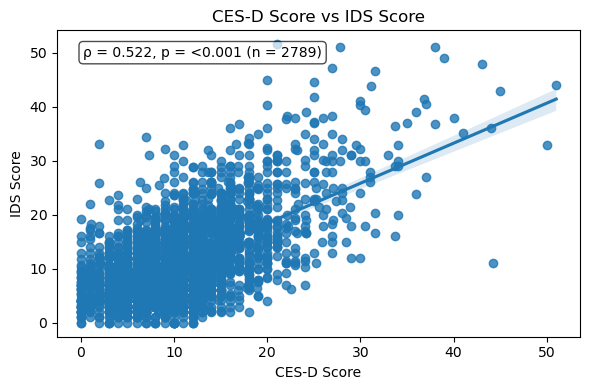


  CES-D Score  ×  GDS-15 Score
  x: CES-D Score
  y: GDS-15 Score
  method: pearson
  n: 2796
  correlation: 0.5681666549173139
  p_value: 8.387004937563501e-239
  effect_size: 0.32281334775993004
  effect_label: r² (variance explained)


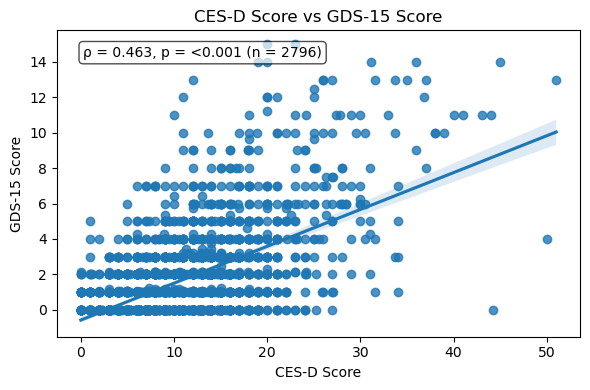


  GAD-7 Score  ×  IDS Score
  x: GAD-7 Score
  y: IDS Score
  method: pearson
  n: 2855
  correlation: 0.5942306287467123
  p_value: 3.544856626776388e-272
  effect_size: 0.353110040140713
  effect_label: r² (variance explained)


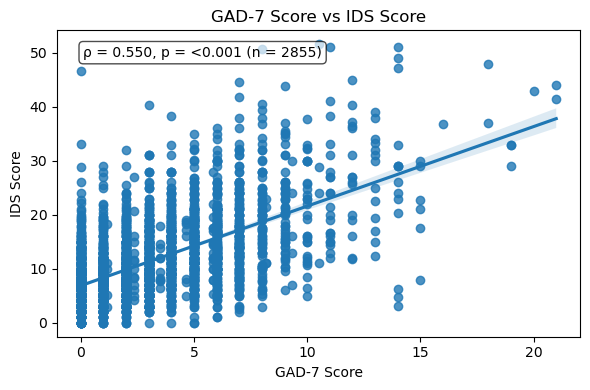


  GAD-7 Score  ×  GDS-15 Score
  x: GAD-7 Score
  y: GDS-15 Score
  method: pearson
  n: 2863
  correlation: 0.4779576250047274
  p_value: 2.3620763675903625e-163
  effect_size: 0.2284434913001596
  effect_label: r² (variance explained)


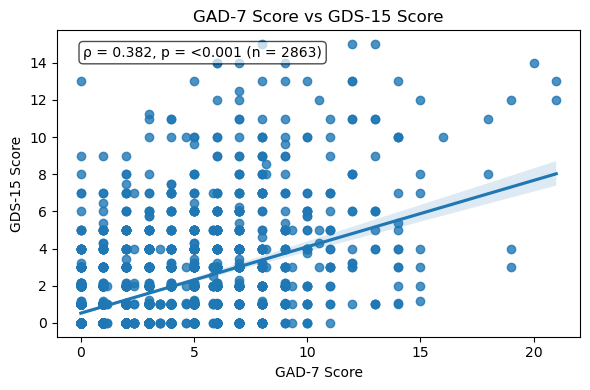


  SWLS Score  ×  IDS Score
  x: SWLS Score
  y: IDS Score
  method: pearson
  n: 2859
  correlation: -0.430013247652438
  p_value: 4.964634552906852e-129
  effect_size: 0.18491139315659696
  effect_label: r² (variance explained)


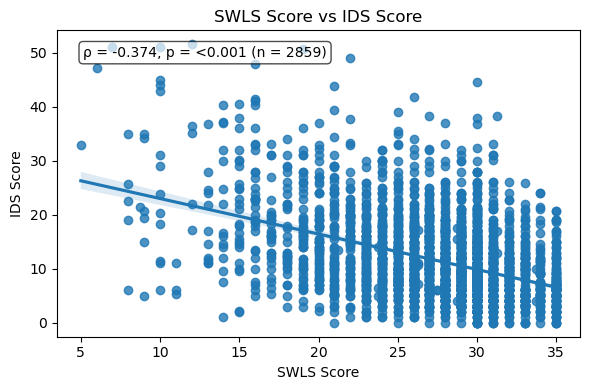


  SWLS Score  ×  GDS-15 Score
  x: SWLS Score
  y: GDS-15 Score
  method: pearson
  n: 2866
  correlation: -0.5250785873788721
  p_value: 7.073029763309883e-203
  effect_size: 0.27570752292379186
  effect_label: r² (variance explained)


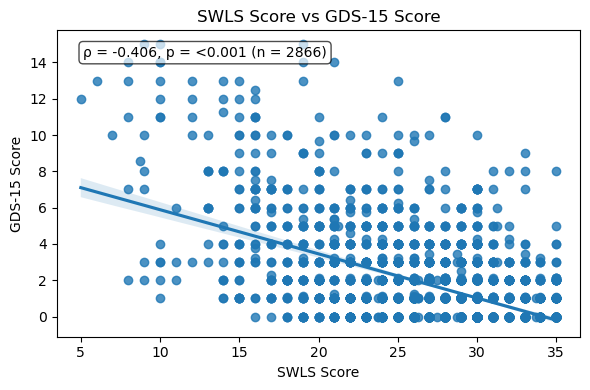

In [34]:
for x_data in cols.mental_numeric:
    for y_data in cols.mental_numeric_2:
        results = bivar.analyze_numeric_numeric(data, x=x_data, y=y_data, method="pearson")
        bivar.plot_numeric_numeric(data, x=x_data, y=y_data);

        # --------------------------------------------------
        # Per-pair output: header → results → figure
        # --------------------------------------------------
        print(f"\n{'='*60}")
        print(f"  {x_data}  ×  {y_data}")
        print(f"{'='*60}")

        for key, val in results.items():
            if isinstance(val, pd.DataFrame):
                print(f"\n{key}:")
                print(val.to_string())
            elif val is not None:
                print(f"  {key}: {val}")

        plt.show()

## Correlation between spatial variables (numeric) – Pearson


  green_100  ×  green_200
  x: green_100
  y: green_200
  method: pearson
  n: 9528
  correlation: 0.7406645932183654
  p_value: 0.0
  effect_size: 0.5485840396473267
  effect_label: r² (variance explained)


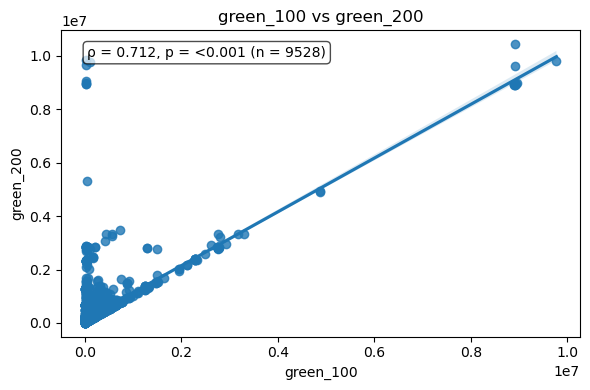


  green_100  ×  green_500
  x: green_100
  y: green_500
  method: pearson
  n: 9528
  correlation: 0.5374994791731588
  p_value: 0.0
  effect_size: 0.2889056901114169
  effect_label: r² (variance explained)


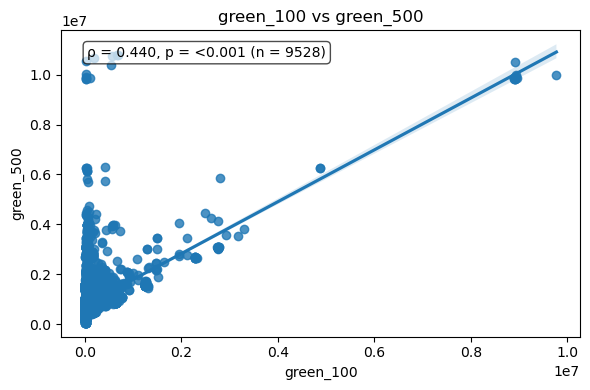


  green_100  ×  green_1000
  x: green_100
  y: green_1000
  method: pearson
  n: 9528
  correlation: 0.3168507234942507
  p_value: 3.644571626790208e-221
  effect_size: 0.1003943809788301
  effect_label: r² (variance explained)


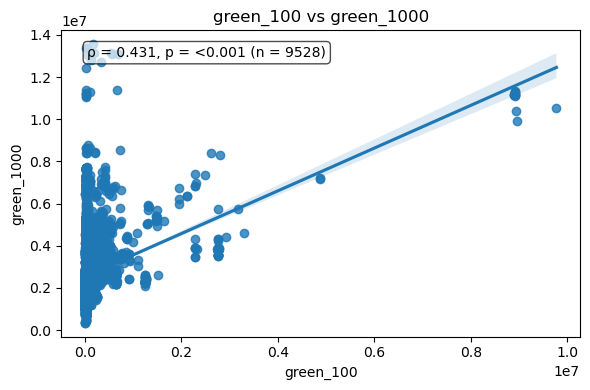


  green_100  ×  NDVI (100m Buffer)
  x: green_100
  y: NDVI (100m Buffer)
  method: pearson
  n: 9528
  correlation: 0.1512057146060732
  p_value: 7.735194910641616e-50
  effect_size: 0.022863168129533262
  effect_label: r² (variance explained)


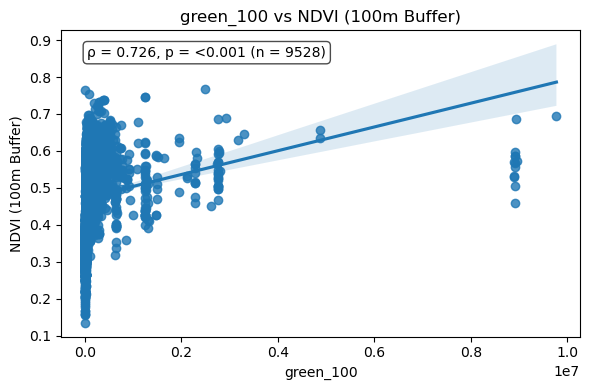


  green_100  ×  NDVI (200m Buffer)
  x: green_100
  y: NDVI (200m Buffer)
  method: pearson
  n: 9528
  correlation: 0.19073137209187246
  p_value: 9.495464642928062e-79
  effect_size: 0.03637845630004831
  effect_label: r² (variance explained)


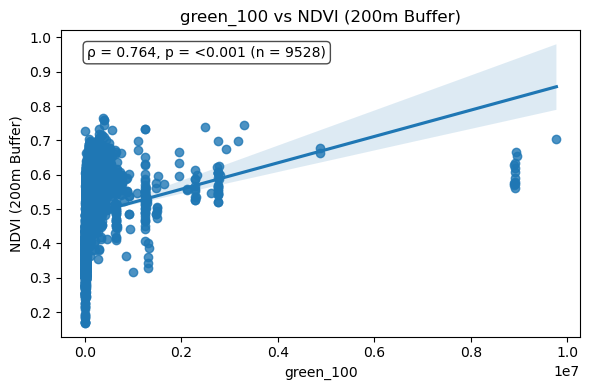


  green_100  ×  NDVI (500m Buffer)
  x: green_100
  y: NDVI (500m Buffer)
  method: pearson
  n: 9528
  correlation: 0.20833302209857166
  p_value: 6.394014362279965e-94
  effect_size: 0.04340264809672394
  effect_label: r² (variance explained)


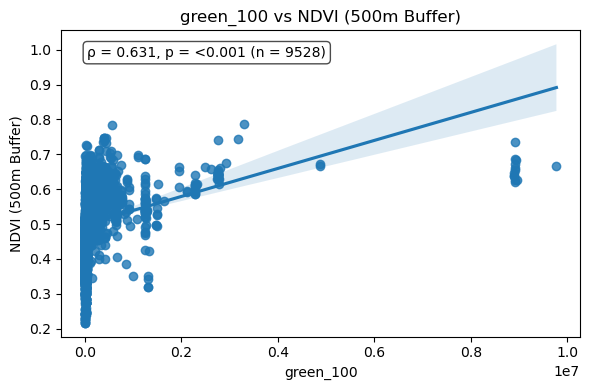


  green_100  ×  NDVI (1000m Buffer)
  x: green_100
  y: NDVI (1000m Buffer)
  method: pearson
  n: 9528
  correlation: 0.1903098224534643
  p_value: 2.1050009241177394e-78
  effect_size: 0.03621782852226911
  effect_label: r² (variance explained)


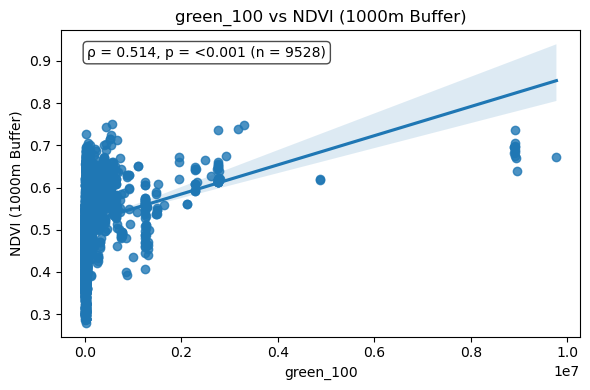


  green_200  ×  green_500
  x: green_200
  y: green_500
  method: pearson
  n: 9528
  correlation: 0.7323445639083487
  p_value: 0.0
  effect_size: 0.5363285602861094
  effect_label: r² (variance explained)


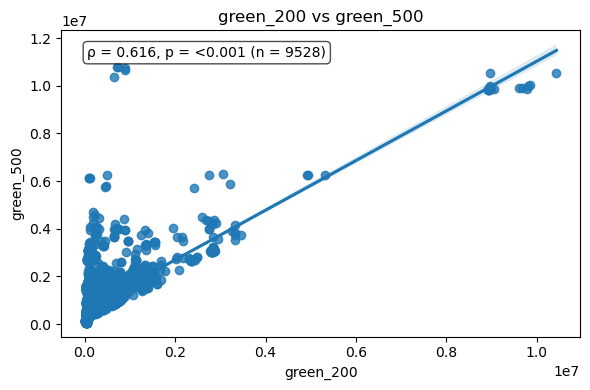


  green_200  ×  green_1000
  x: green_200
  y: green_1000
  method: pearson
  n: 9528
  correlation: 0.4530088364824761
  p_value: 0.0
  effect_size: 0.20521700593120676
  effect_label: r² (variance explained)


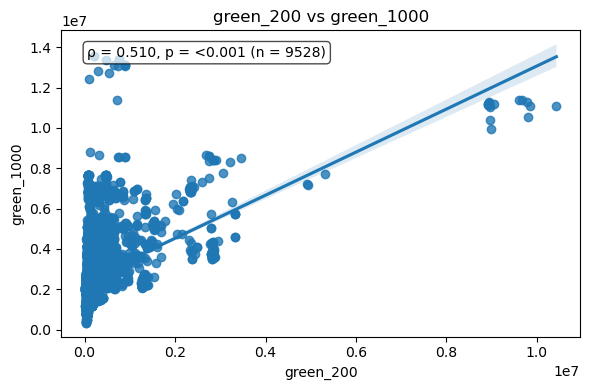


  green_200  ×  NDVI (100m Buffer)
  x: green_200
  y: NDVI (100m Buffer)
  method: pearson
  n: 9528
  correlation: 0.1711801588787336
  p_value: 1.4383968825952852e-63
  effect_size: 0.029302646793748482
  effect_label: r² (variance explained)


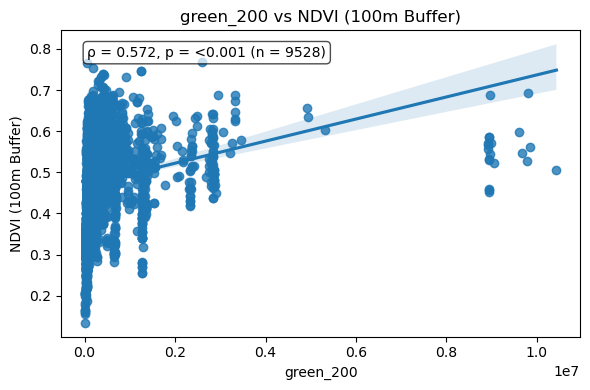


  green_200  ×  NDVI (200m Buffer)
  x: green_200
  y: NDVI (200m Buffer)
  method: pearson
  n: 9528
  correlation: 0.2323019477150164
  p_value: 6.2143898885587675e-117
  effect_size: 0.053964194912190205
  effect_label: r² (variance explained)


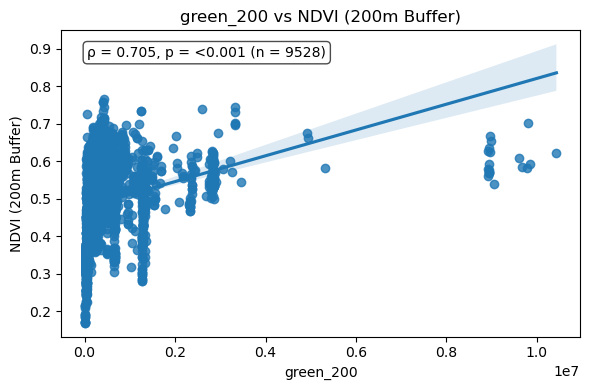


  green_200  ×  NDVI (500m Buffer)
  x: green_200
  y: NDVI (500m Buffer)
  method: pearson
  n: 9528
  correlation: 0.29806303261462175
  p_value: 9.625650866314419e-195
  effect_size: 0.08884157141142507
  effect_label: r² (variance explained)


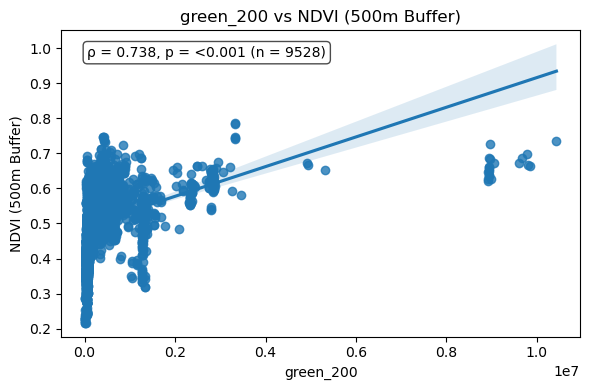


  green_200  ×  NDVI (1000m Buffer)
  x: green_200
  y: NDVI (1000m Buffer)
  method: pearson
  n: 9528
  correlation: 0.27919230212699103
  p_value: 3.9382561134171734e-170
  effect_size: 0.07794834156696905
  effect_label: r² (variance explained)


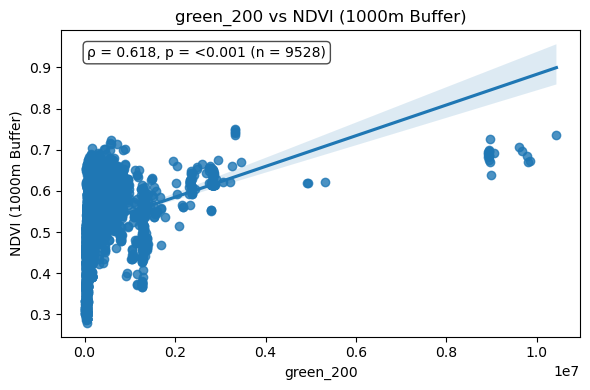


  green_500  ×  green_1000
  x: green_500
  y: green_1000
  method: pearson
  n: 9528
  correlation: 0.657465820917812
  p_value: 0.0
  effect_size: 0.4322613056751325
  effect_label: r² (variance explained)


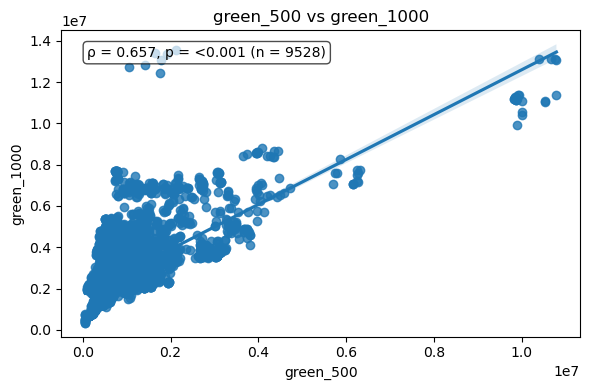


  green_500  ×  NDVI (100m Buffer)
  x: green_500
  y: NDVI (100m Buffer)
  method: pearson
  n: 9528
  correlation: 0.223717086104527
  p_value: 2.2491612909435706e-108
  effect_size: 0.050049334615100353
  effect_label: r² (variance explained)


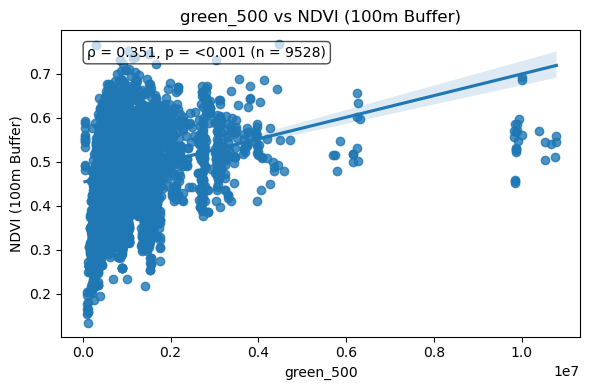


  green_500  ×  NDVI (200m Buffer)
  x: green_500
  y: NDVI (200m Buffer)
  method: pearson
  n: 9528
  correlation: 0.2919795041023571
  p_value: 1.3349304933525772e-186
  effect_size: 0.08525203081585839
  effect_label: r² (variance explained)


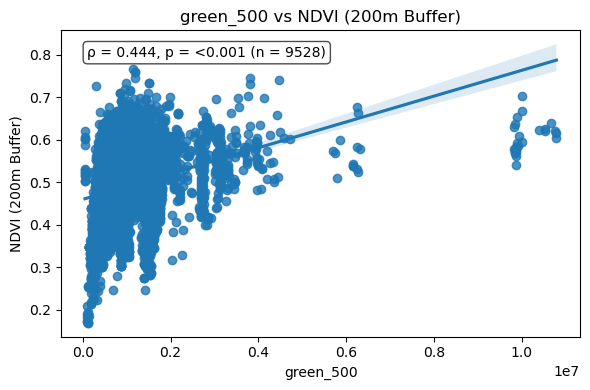


  green_500  ×  NDVI (500m Buffer)
  x: green_500
  y: NDVI (500m Buffer)
  method: pearson
  n: 9528
  correlation: 0.4028852825106079
  p_value: 0.0
  effect_size: 0.16231655086365235
  effect_label: r² (variance explained)


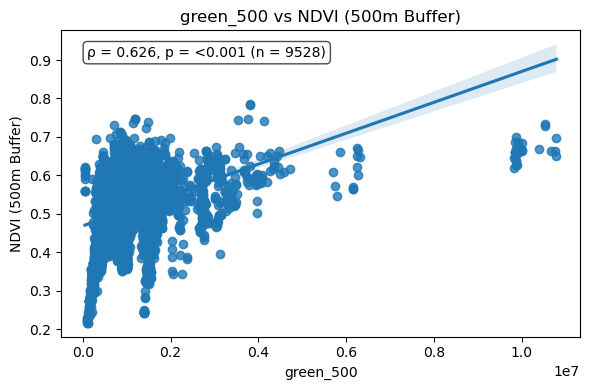


  green_500  ×  NDVI (1000m Buffer)
  x: green_500
  y: NDVI (1000m Buffer)
  method: pearson
  n: 9528
  correlation: 0.433627786329259
  p_value: 0.0
  effect_size: 0.18803305707681353
  effect_label: r² (variance explained)


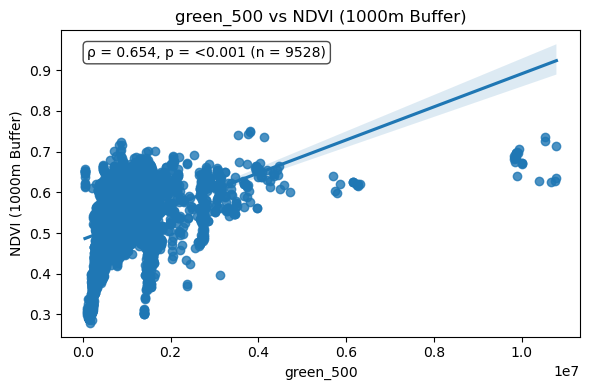


  green_1000  ×  NDVI (100m Buffer)
  x: green_1000
  y: NDVI (100m Buffer)
  method: pearson
  n: 9528
  correlation: 0.2924270213664689
  p_value: 3.414295419265519e-187
  effect_size: 0.08551356282526527
  effect_label: r² (variance explained)


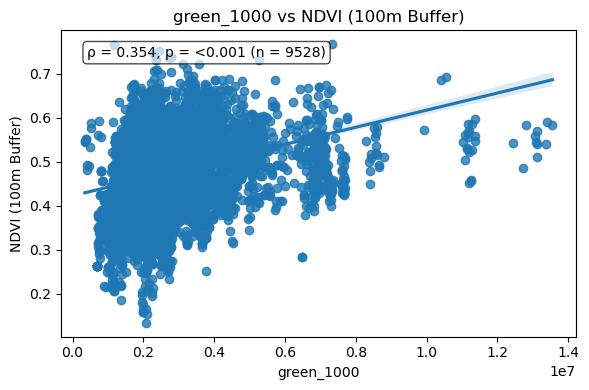


  green_1000  ×  NDVI (200m Buffer)
  x: green_1000
  y: NDVI (200m Buffer)
  method: pearson
  n: 9528
  correlation: 0.3548517156874378
  p_value: 9.354295384743301e-281
  effect_size: 0.12591974012631818
  effect_label: r² (variance explained)


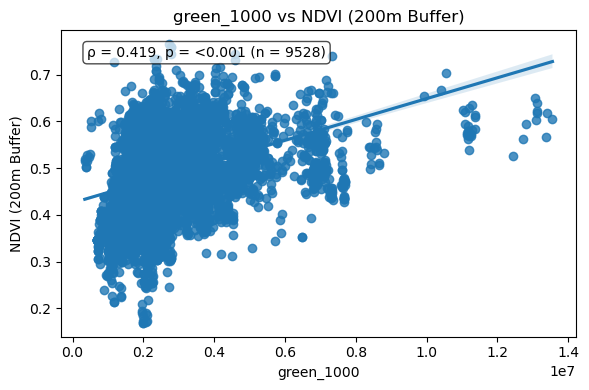


  green_1000  ×  NDVI (500m Buffer)
  x: green_1000
  y: NDVI (500m Buffer)
  method: pearson
  n: 9528
  correlation: 0.45254568419410085
  p_value: 0.0
  effect_size: 0.20479759628270686
  effect_label: r² (variance explained)


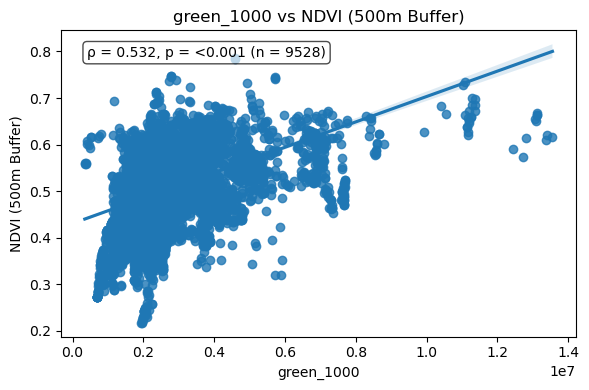


  green_1000  ×  NDVI (1000m Buffer)
  x: green_1000
  y: NDVI (1000m Buffer)
  method: pearson
  n: 9528
  correlation: 0.5427234155457343
  p_value: 0.0
  effect_size: 0.29454870578162784
  effect_label: r² (variance explained)


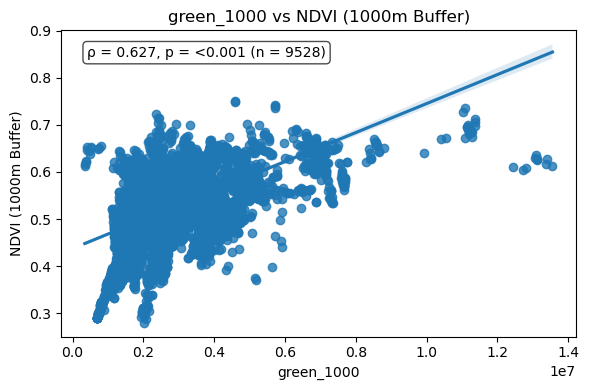


  NDVI (100m Buffer)  ×  NDVI (200m Buffer)
  x: NDVI (100m Buffer)
  y: NDVI (200m Buffer)
  method: pearson
  n: 9568
  correlation: 0.9062686545313059
  p_value: 0.0
  effect_size: 0.8213228741859835
  effect_label: r² (variance explained)


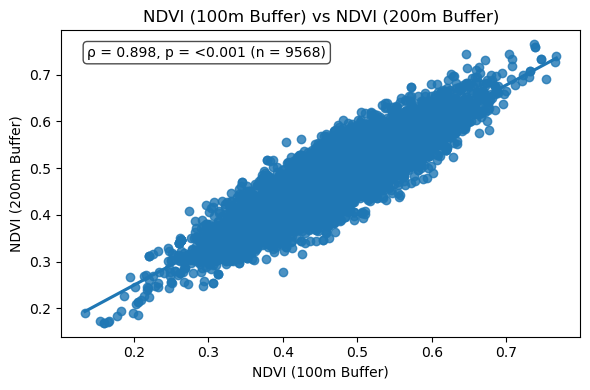


  NDVI (100m Buffer)  ×  NDVI (500m Buffer)
  x: NDVI (100m Buffer)
  y: NDVI (500m Buffer)
  method: pearson
  n: 9568
  correlation: 0.6790416254026912
  p_value: 0.0
  effect_size: 0.4610975290295288
  effect_label: r² (variance explained)


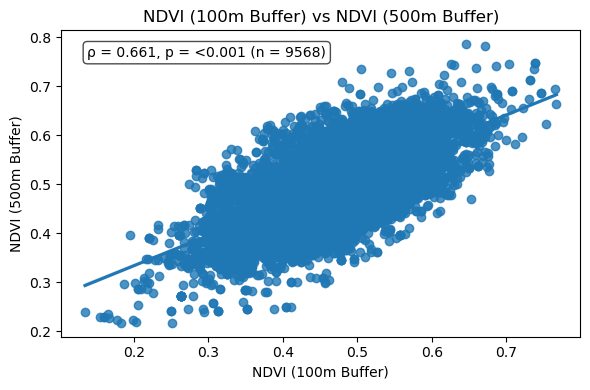


  NDVI (100m Buffer)  ×  NDVI (1000m Buffer)
  x: NDVI (100m Buffer)
  y: NDVI (1000m Buffer)
  method: pearson
  n: 9568
  correlation: 0.5487502113815665
  p_value: 0.0
  effect_size: 0.30112679449131396
  effect_label: r² (variance explained)


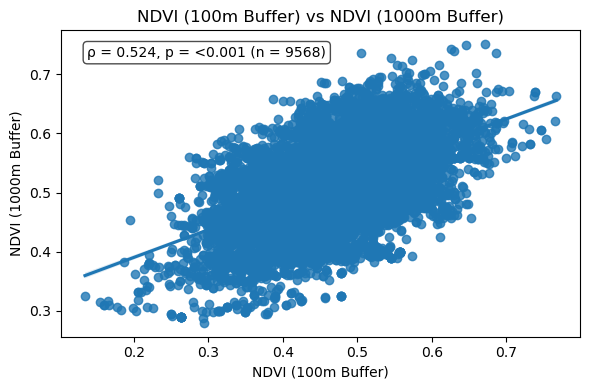


  NDVI (200m Buffer)  ×  NDVI (500m Buffer)
  x: NDVI (200m Buffer)
  y: NDVI (500m Buffer)
  method: pearson
  n: 9568
  correlation: 0.8280590956497742
  p_value: 0.0
  effect_size: 0.6856818658883219
  effect_label: r² (variance explained)


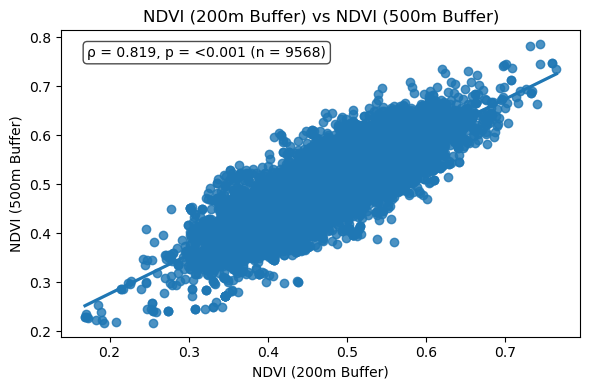


  NDVI (200m Buffer)  ×  NDVI (1000m Buffer)
  x: NDVI (200m Buffer)
  y: NDVI (1000m Buffer)
  method: pearson
  n: 9568
  correlation: 0.6659073028508042
  p_value: 0.0
  effect_size: 0.44343253599003274
  effect_label: r² (variance explained)


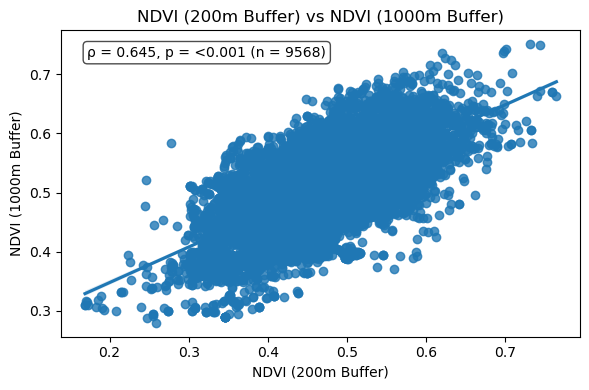


  NDVI (500m Buffer)  ×  NDVI (1000m Buffer)
  x: NDVI (500m Buffer)
  y: NDVI (1000m Buffer)
  method: pearson
  n: 9568
  correlation: 0.8810476928646078
  p_value: 0.0
  effect_size: 0.7762450371020483
  effect_label: r² (variance explained)


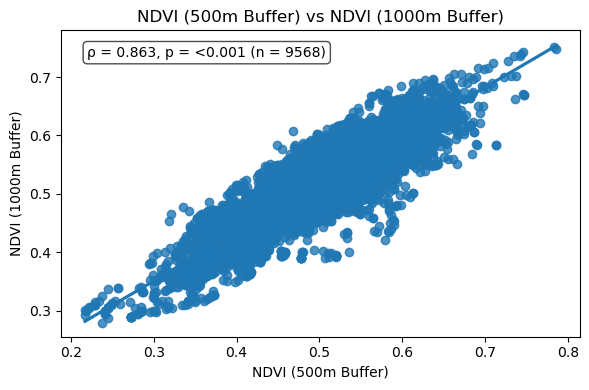

In [35]:
numeric_vars = cols.greenspace_raw + cols.ndvi #cols.greenspace_quartiles
rows = []
for ii, x_data in enumerate(numeric_vars):
    for y_data in numeric_vars[ii + 1:]:
        results = bivar.analyze_numeric_numeric(data, x=x_data, y=y_data, method="pearson")
        bivar.plot_numeric_numeric(data, x=x_data, y=y_data);

        #rows.append({k: results[k] for k in ('x', 'y', 'method', 'n', 'correlation')})
        rows.append(results)
        # --------------------------------------------------
        # Per-pair output: header → results → figure
        # --------------------------------------------------
        print(f"\n{'='*60}")
        print(f"  {x_data}  ×  {y_data}")
        print(f"{'='*60}")

        for key, val in results.items():
            if isinstance(val, pd.DataFrame):
                print(f"\n{key}:")
                print(val.to_string())
            elif val is not None:
                print(f"  {key}: {val}")

        plt.show()

df_corr_spatial = pd.DataFrame(rows)

In [36]:
mask = df_corr_spatial['x'].isin(cols.greenspace_raw) & df_corr_spatial['y'].isin(cols.greenspace_raw)
df_corr_spatial[mask]

,x,y,method,n,correlation,p_value,effect_size,effect_label
0,green_100,green_200,pearson,9528,0.740665,0.000000e+00,0.548584,r² (variance explained)
1,green_100,green_500,pearson,9528,0.537499,0.000000e+00,0.288906,r² (variance explained)
2,green_100,green_1000,pearson,9528,0.316851,3.644572e-221,0.100394,r² (variance explained)
7,green_200,green_500,pearson,9528,0.732345,0.000000e+00,0.536329,r² (variance explained)
8,green_200,green_1000,pearson,9528,0.453009,0.000000e+00,0.205217,r² (variance explained)
13,green_500,green_1000,pearson,9528,0.657466,0.000000e+00,0.432261,r² (variance explained)


In [37]:
mask = df_corr_spatial['x'].isin(cols.ndvi) & df_corr_spatial['y'].isin(cols.ndvi)
df_corr_spatial[mask]

,x,y,method,n,correlation,p_value,effect_size,effect_label
22,NDVI (100m Buffer),NDVI (200m Buffer),pearson,9568,0.906269,0.0,0.821323,r² (variance explained)
23,NDVI (100m Buffer),NDVI (500m Buffer),pearson,9568,0.679042,0.0,0.461098,r² (variance explained)
24,NDVI (100m Buffer),NDVI (1000m Buffer),pearson,9568,0.548750,0.0,0.301127,r² (variance explained)
25,NDVI (200m Buffer),NDVI (500m Buffer),pearson,9568,0.828059,0.0,0.685682,r² (variance explained)
26,NDVI (200m Buffer),NDVI (1000m Buffer),pearson,9568,0.665907,0.0,0.443433,r² (variance explained)
27,NDVI (500m Buffer),NDVI (1000m Buffer),pearson,9568,0.881048,0.0,0.776245,r² (variance explained)


In [38]:
mask = df_corr_spatial['x'].isin(cols.greenspace_raw) & df_corr_spatial['y'].isin(cols.ndvi)
df_corr_spatial[mask]

,x,y,method,n,correlation,p_value,effect_size,effect_label
3,green_100,NDVI (100m Buffer),pearson,9528,0.151206,7.735195e-50,0.022863,r² (variance explained)
4,green_100,NDVI (200m Buffer),pearson,9528,0.190731,9.495465e-79,0.036378,r² (variance explained)
5,green_100,NDVI (500m Buffer),pearson,9528,0.208333,6.394014e-94,0.043403,r² (variance explained)
6,green_100,NDVI (1000m Buffer),pearson,9528,0.190310,2.105001e-78,0.036218,r² (variance explained)
9,green_200,NDVI (100m Buffer),pearson,9528,0.171180,1.438397e-63,0.029303,r² (variance explained)
10,green_200,NDVI (200m Buffer),pearson,9528,0.232302,6.214390e-117,0.053964,r² (variance explained)
11,green_200,NDVI (500m Buffer),pearson,9528,0.298063,9.625651e-195,0.088842,r² (variance explained)
12,green_200,NDVI (1000m Buffer),pearson,9528,0.279192,3.938256e-170,0.077948,r² (variance explained)
14,green_500,NDVI (100m Buffer),pearson,9528,0.223717,2.249161e-108,0.050049,r² (variance explained)
15,green_500,NDVI (200m Buffer),pearson,9528,0.291980,1.334930e-186,0.085252,r² (variance explained)


## Correlation between spatial variables (numeric) – Spearman


  green_100  ×  green_200
  x: green_100
  y: green_200
  method: spearman
  n: 9528
  correlation: 0.7118662840387965
  p_value: 0.0
  effect_size: 0.7118662840387965
  effect_label: rho (Spearman)


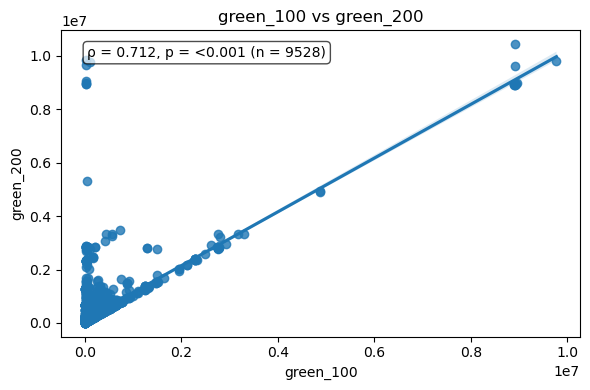


  green_100  ×  green_500
  x: green_100
  y: green_500
  method: spearman
  n: 9528
  correlation: 0.4402219817187634
  p_value: 0.0
  effect_size: 0.4402219817187634
  effect_label: rho (Spearman)


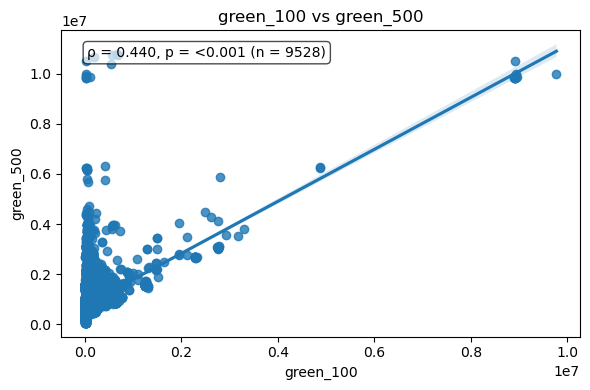


  green_100  ×  green_1000
  x: green_100
  y: green_1000
  method: spearman
  n: 9528
  correlation: 0.4309857964613881
  p_value: 0.0
  effect_size: 0.4309857964613881
  effect_label: rho (Spearman)


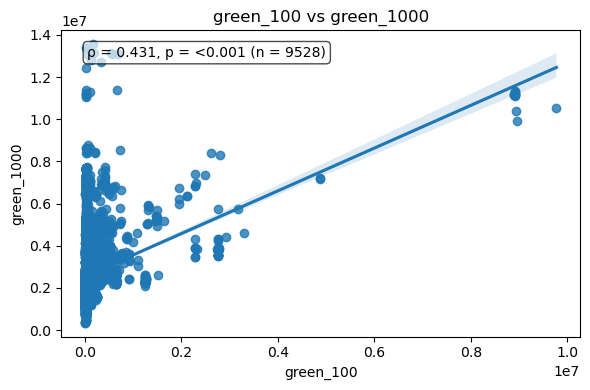


  green_100  ×  NDVI (100m Buffer)
  x: green_100
  y: NDVI (100m Buffer)
  method: spearman
  n: 9528
  correlation: 0.7264132317921699
  p_value: 0.0
  effect_size: 0.7264132317921699
  effect_label: rho (Spearman)


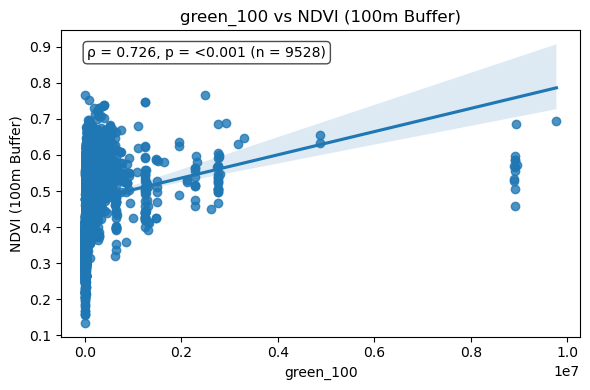


  green_100  ×  NDVI (200m Buffer)
  x: green_100
  y: NDVI (200m Buffer)
  method: spearman
  n: 9528
  correlation: 0.7641197364193257
  p_value: 0.0
  effect_size: 0.7641197364193257
  effect_label: rho (Spearman)


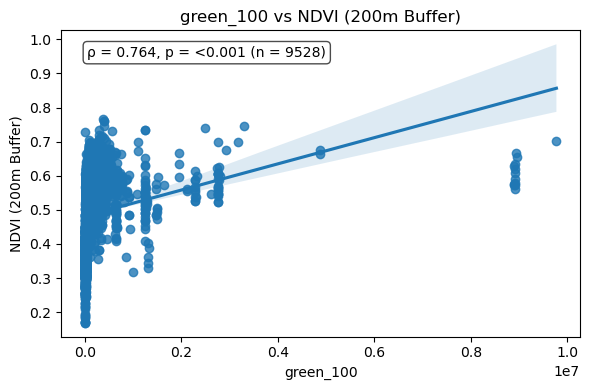


  green_100  ×  NDVI (500m Buffer)
  x: green_100
  y: NDVI (500m Buffer)
  method: spearman
  n: 9528
  correlation: 0.6310210854581386
  p_value: 0.0
  effect_size: 0.6310210854581386
  effect_label: rho (Spearman)


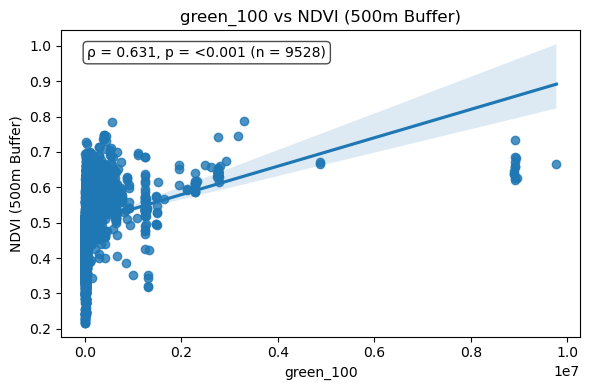


  green_100  ×  NDVI (1000m Buffer)
  x: green_100
  y: NDVI (1000m Buffer)
  method: spearman
  n: 9528
  correlation: 0.5140736783843507
  p_value: 0.0
  effect_size: 0.5140736783843507
  effect_label: rho (Spearman)


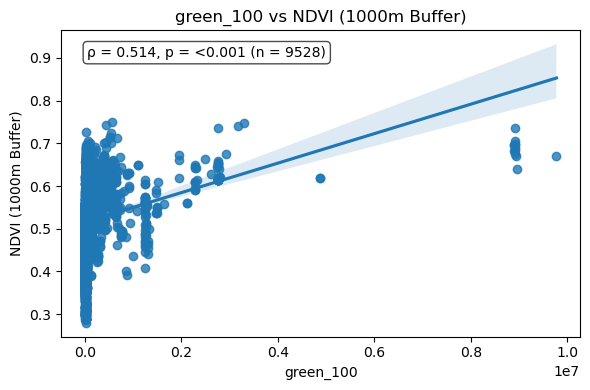


  green_200  ×  green_500
  x: green_200
  y: green_500
  method: spearman
  n: 9528
  correlation: 0.6159555200372042
  p_value: 0.0
  effect_size: 0.6159555200372042
  effect_label: rho (Spearman)


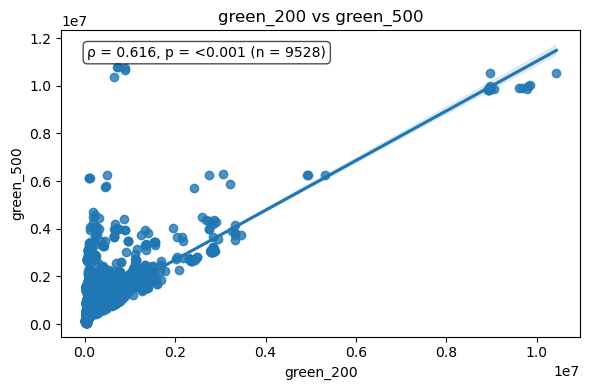


  green_200  ×  green_1000
  x: green_200
  y: green_1000
  method: spearman
  n: 9528
  correlation: 0.5095969986875718
  p_value: 0.0
  effect_size: 0.5095969986875718
  effect_label: rho (Spearman)


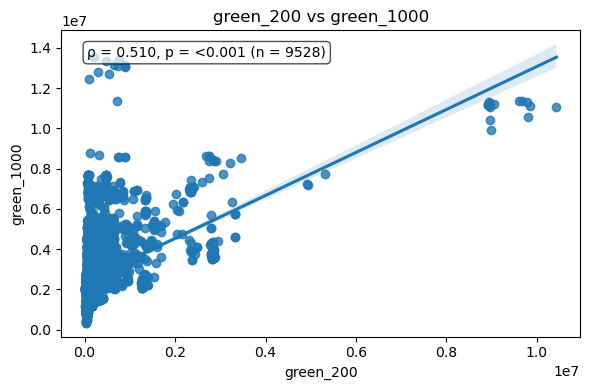


  green_200  ×  NDVI (100m Buffer)
  x: green_200
  y: NDVI (100m Buffer)
  method: spearman
  n: 9528
  correlation: 0.5715012022064991
  p_value: 0.0
  effect_size: 0.5715012022064991
  effect_label: rho (Spearman)


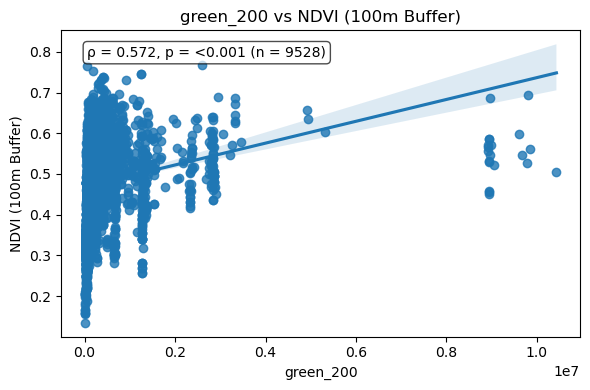


  green_200  ×  NDVI (200m Buffer)
  x: green_200
  y: NDVI (200m Buffer)
  method: spearman
  n: 9528
  correlation: 0.704536095861881
  p_value: 0.0
  effect_size: 0.704536095861881
  effect_label: rho (Spearman)


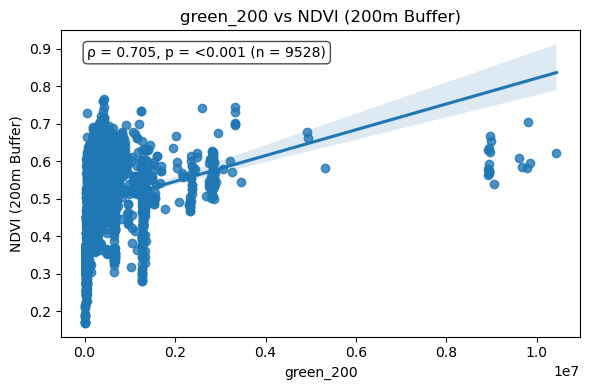


  green_200  ×  NDVI (500m Buffer)
  x: green_200
  y: NDVI (500m Buffer)
  method: spearman
  n: 9528
  correlation: 0.7381180919950727
  p_value: 0.0
  effect_size: 0.7381180919950727
  effect_label: rho (Spearman)


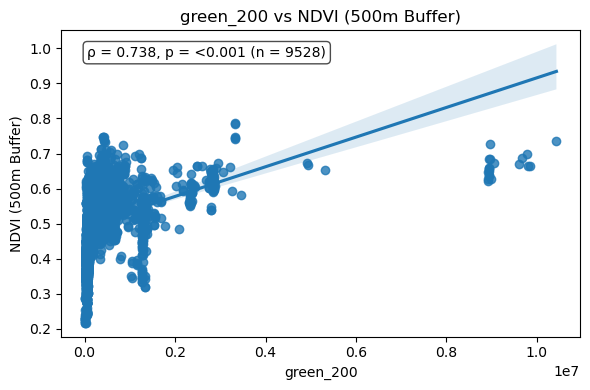


  green_200  ×  NDVI (1000m Buffer)
  x: green_200
  y: NDVI (1000m Buffer)
  method: spearman
  n: 9528
  correlation: 0.617729785262525
  p_value: 0.0
  effect_size: 0.617729785262525
  effect_label: rho (Spearman)


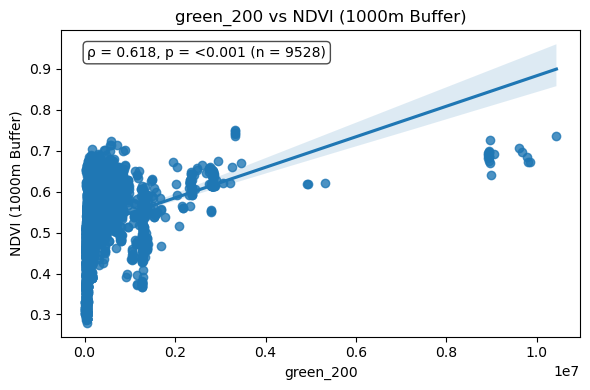


  green_500  ×  green_1000
  x: green_500
  y: green_1000
  method: spearman
  n: 9528
  correlation: 0.6568580485134594
  p_value: 0.0
  effect_size: 0.6568580485134594
  effect_label: rho (Spearman)


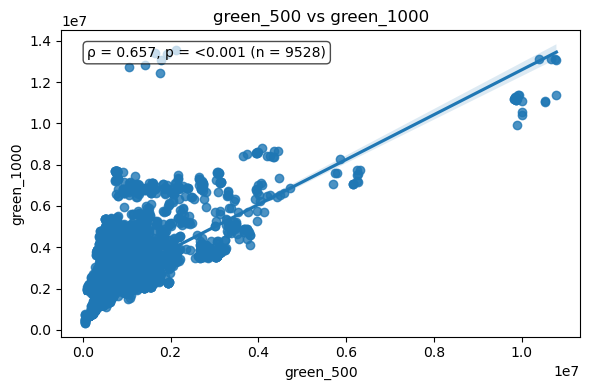


  green_500  ×  NDVI (100m Buffer)
  x: green_500
  y: NDVI (100m Buffer)
  method: spearman
  n: 9528
  correlation: 0.35123883195880595
  p_value: 1.0086715322596108e-274
  effect_size: 0.35123883195880595
  effect_label: rho (Spearman)


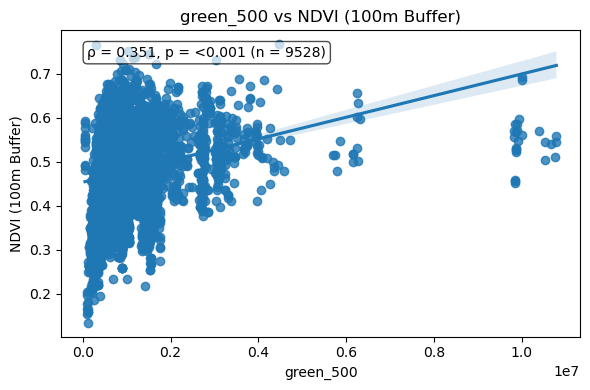


  green_500  ×  NDVI (200m Buffer)
  x: green_500
  y: NDVI (200m Buffer)
  method: spearman
  n: 9528
  correlation: 0.44398079819928593
  p_value: 0.0
  effect_size: 0.44398079819928593
  effect_label: rho (Spearman)


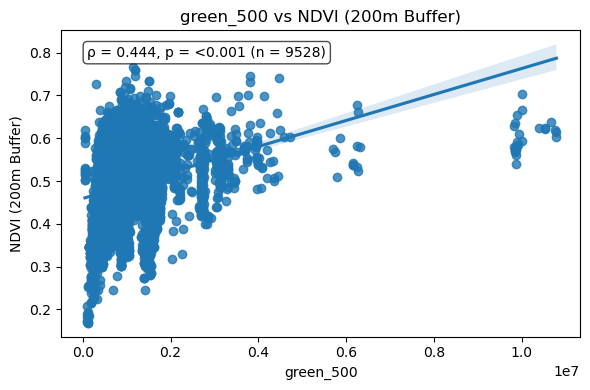


  green_500  ×  NDVI (500m Buffer)
  x: green_500
  y: NDVI (500m Buffer)
  method: spearman
  n: 9528
  correlation: 0.6262596373254972
  p_value: 0.0
  effect_size: 0.6262596373254972
  effect_label: rho (Spearman)


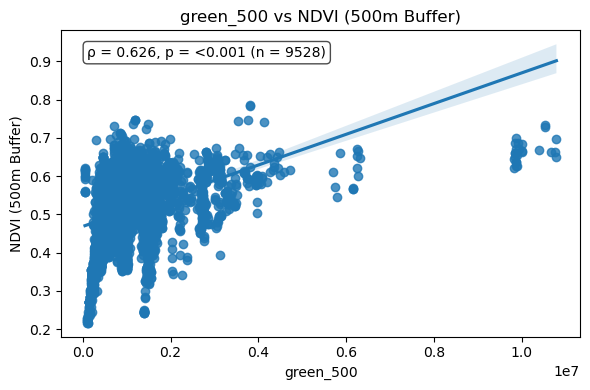


  green_500  ×  NDVI (1000m Buffer)
  x: green_500
  y: NDVI (1000m Buffer)
  method: spearman
  n: 9528
  correlation: 0.6537234790536893
  p_value: 0.0
  effect_size: 0.6537234790536893
  effect_label: rho (Spearman)


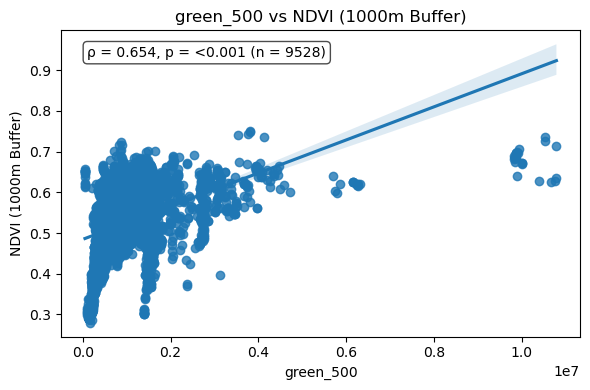


  green_1000  ×  NDVI (100m Buffer)
  x: green_1000
  y: NDVI (100m Buffer)
  method: spearman
  n: 9528
  correlation: 0.35448882469297527
  p_value: 3.8066548299668822e-280
  effect_size: 0.35448882469297527
  effect_label: rho (Spearman)


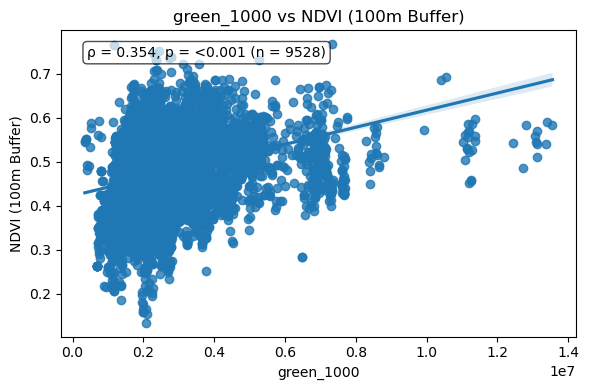


  green_1000  ×  NDVI (200m Buffer)
  x: green_1000
  y: NDVI (200m Buffer)
  method: spearman
  n: 9528
  correlation: 0.41910880749156837
  p_value: 0.0
  effect_size: 0.41910880749156837
  effect_label: rho (Spearman)


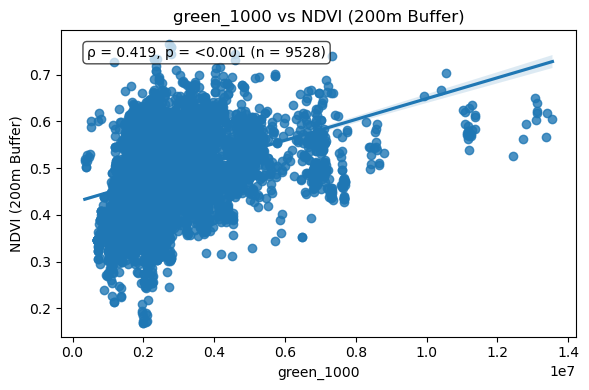


  green_1000  ×  NDVI (500m Buffer)
  x: green_1000
  y: NDVI (500m Buffer)
  method: spearman
  n: 9528
  correlation: 0.531624800504932
  p_value: 0.0
  effect_size: 0.531624800504932
  effect_label: rho (Spearman)


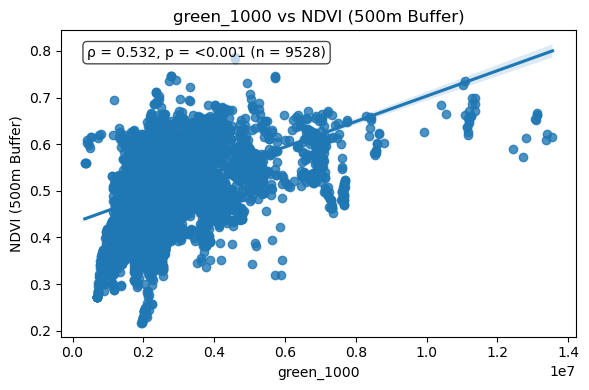


  green_1000  ×  NDVI (1000m Buffer)
  x: green_1000
  y: NDVI (1000m Buffer)
  method: spearman
  n: 9528
  correlation: 0.627069059583948
  p_value: 0.0
  effect_size: 0.627069059583948
  effect_label: rho (Spearman)


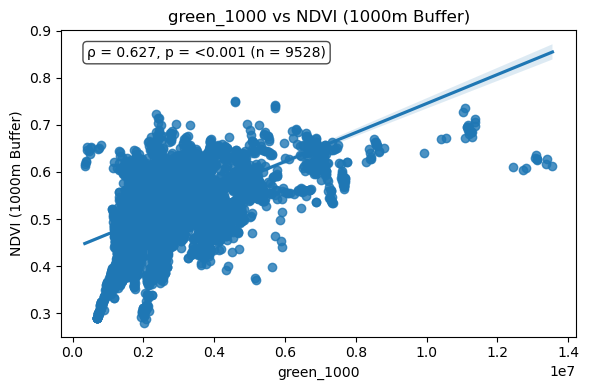


  NDVI (100m Buffer)  ×  NDVI (200m Buffer)
  x: NDVI (100m Buffer)
  y: NDVI (200m Buffer)
  method: spearman
  n: 9568
  correlation: 0.8982368738109077
  p_value: 0.0
  effect_size: 0.8982368738109077
  effect_label: rho (Spearman)


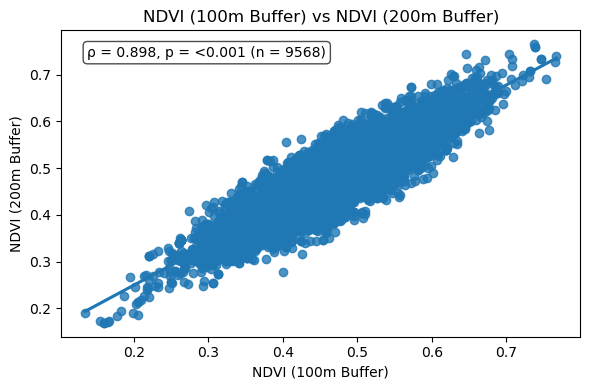


  NDVI (100m Buffer)  ×  NDVI (500m Buffer)
  x: NDVI (100m Buffer)
  y: NDVI (500m Buffer)
  method: spearman
  n: 9568
  correlation: 0.6613898130486597
  p_value: 0.0
  effect_size: 0.6613898130486597
  effect_label: rho (Spearman)


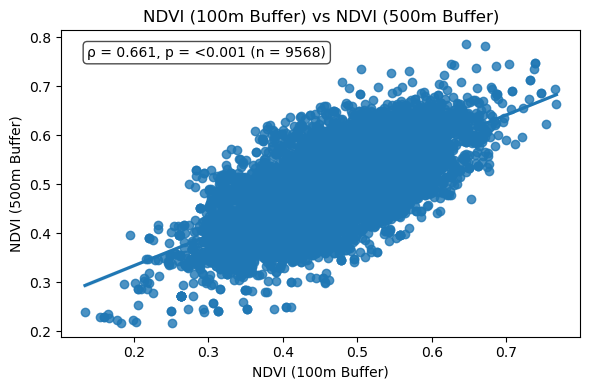


  NDVI (100m Buffer)  ×  NDVI (1000m Buffer)
  x: NDVI (100m Buffer)
  y: NDVI (1000m Buffer)
  method: spearman
  n: 9568
  correlation: 0.523538126685191
  p_value: 0.0
  effect_size: 0.523538126685191
  effect_label: rho (Spearman)


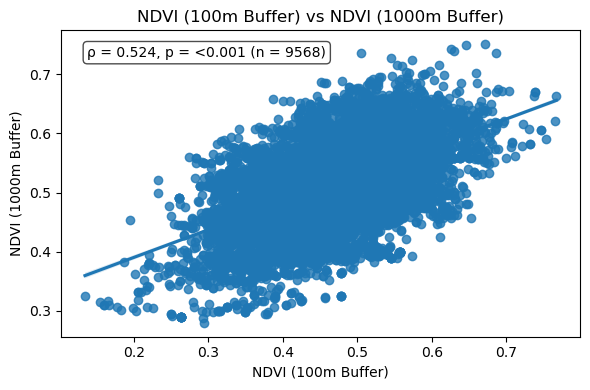


  NDVI (200m Buffer)  ×  NDVI (500m Buffer)
  x: NDVI (200m Buffer)
  y: NDVI (500m Buffer)
  method: spearman
  n: 9568
  correlation: 0.8193471236319219
  p_value: 0.0
  effect_size: 0.8193471236319219
  effect_label: rho (Spearman)


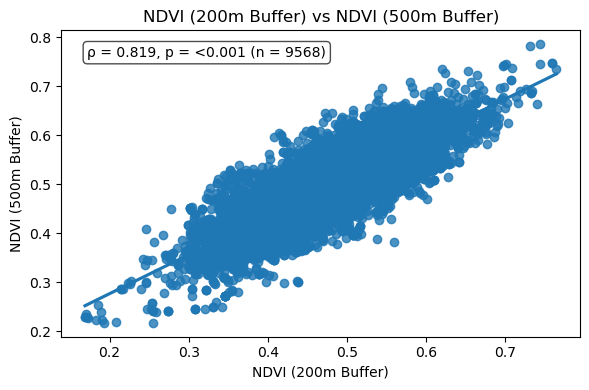


  NDVI (200m Buffer)  ×  NDVI (1000m Buffer)
  x: NDVI (200m Buffer)
  y: NDVI (1000m Buffer)
  method: spearman
  n: 9568
  correlation: 0.644529525900399
  p_value: 0.0
  effect_size: 0.644529525900399
  effect_label: rho (Spearman)


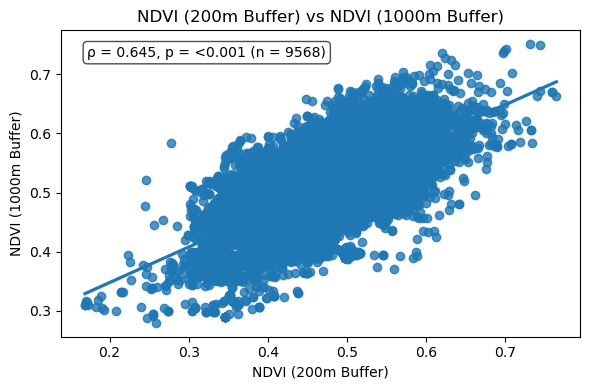


  NDVI (500m Buffer)  ×  NDVI (1000m Buffer)
  x: NDVI (500m Buffer)
  y: NDVI (1000m Buffer)
  method: spearman
  n: 9568
  correlation: 0.8634977772808458
  p_value: 0.0
  effect_size: 0.8634977772808458
  effect_label: rho (Spearman)


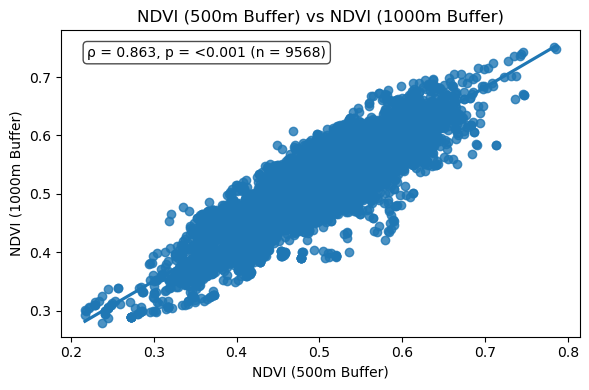

In [39]:
numeric_vars = cols.greenspace_raw + cols.ndvi #cols.greenspace_quartiles
rows = []
for ii, x_data in enumerate(numeric_vars):
    for y_data in numeric_vars[ii + 1:]:
        results = bivar.analyze_numeric_numeric(data, x=x_data, y=y_data, method="spearman")
        bivar.plot_numeric_numeric(data, x=x_data, y=y_data);

        #rows.append({k: results[k] for k in ('x', 'y', 'method', 'n', 'correlation')})
        rows.append(results)
        # --------------------------------------------------
        # Per-pair output: header → results → figure
        # --------------------------------------------------
        print(f"\n{'='*60}")
        print(f"  {x_data}  ×  {y_data}")
        print(f"{'='*60}")

        for key, val in results.items():
            if isinstance(val, pd.DataFrame):
                print(f"\n{key}:")
                print(val.to_string())
            elif val is not None:
                print(f"  {key}: {val}")

        plt.show()

df_corr_spatial = pd.DataFrame(rows)

### Green Space measures

In [40]:
mask = df_corr_spatial['x'].isin(cols.greenspace_raw) & df_corr_spatial['y'].isin(cols.greenspace_raw)
df_corr_spatial[mask]

,x,y,method,n,correlation,p_value,effect_size,effect_label
0,green_100,green_200,spearman,9528,0.711866,0.0,0.711866,rho (Spearman)
1,green_100,green_500,spearman,9528,0.440222,0.0,0.440222,rho (Spearman)
2,green_100,green_1000,spearman,9528,0.430986,0.0,0.430986,rho (Spearman)
7,green_200,green_500,spearman,9528,0.615956,0.0,0.615956,rho (Spearman)
8,green_200,green_1000,spearman,9528,0.509597,0.0,0.509597,rho (Spearman)
13,green_500,green_1000,spearman,9528,0.656858,0.0,0.656858,rho (Spearman)


### NDVI

In [42]:
mask = df_corr_spatial['x'].isin(cols.ndvi) & df_corr_spatial['y'].isin(cols.ndvi)
df_corr_spatial[mask]

,x,y,method,n,correlation,p_value,effect_size,effect_label
22,NDVI (100m Buffer),NDVI (200m Buffer),spearman,9568,0.898237,0.0,0.898237,rho (Spearman)
23,NDVI (100m Buffer),NDVI (500m Buffer),spearman,9568,0.661390,0.0,0.661390,rho (Spearman)
24,NDVI (100m Buffer),NDVI (1000m Buffer),spearman,9568,0.523538,0.0,0.523538,rho (Spearman)
25,NDVI (200m Buffer),NDVI (500m Buffer),spearman,9568,0.819347,0.0,0.819347,rho (Spearman)
26,NDVI (200m Buffer),NDVI (1000m Buffer),spearman,9568,0.644530,0.0,0.644530,rho (Spearman)
27,NDVI (500m Buffer),NDVI (1000m Buffer),spearman,9568,0.863498,0.0,0.863498,rho (Spearman)


### Mixed – Green Space measures & NDVI

In [44]:
mask = df_corr_spatial['x'].isin(cols.greenspace_raw) & df_corr_spatial['y'].isin(cols.ndvi)
df_corr_spatial[mask]

,x,y,method,n,correlation,p_value,effect_size,effect_label
3,green_100,NDVI (100m Buffer),spearman,9528,0.726413,0.000000e+00,0.726413,rho (Spearman)
4,green_100,NDVI (200m Buffer),spearman,9528,0.764120,0.000000e+00,0.764120,rho (Spearman)
5,green_100,NDVI (500m Buffer),spearman,9528,0.631021,0.000000e+00,0.631021,rho (Spearman)
6,green_100,NDVI (1000m Buffer),spearman,9528,0.514074,0.000000e+00,0.514074,rho (Spearman)
9,green_200,NDVI (100m Buffer),spearman,9528,0.571501,0.000000e+00,0.571501,rho (Spearman)
10,green_200,NDVI (200m Buffer),spearman,9528,0.704536,0.000000e+00,0.704536,rho (Spearman)
11,green_200,NDVI (500m Buffer),spearman,9528,0.738118,0.000000e+00,0.738118,rho (Spearman)
12,green_200,NDVI (1000m Buffer),spearman,9528,0.617730,0.000000e+00,0.617730,rho (Spearman)
14,green_500,NDVI (100m Buffer),spearman,9528,0.351239,1.008672e-274,0.351239,rho (Spearman)
15,green_500,NDVI (200m Buffer),spearman,9528,0.443981,0.000000e+00,0.443981,rho (Spearman)


## Correlation between Mental scores and NDVI (numeric) – Pearson


  CES-D Score  ×  NDVI (100m Buffer)
  x: CES-D Score
  y: NDVI (100m Buffer)
  method: pearson
  n: 9142
  correlation: -0.031186369380703988
  p_value: 0.002862176323580858
  effect_size: 0.0009725896351497112
  effect_label: r² (variance explained)


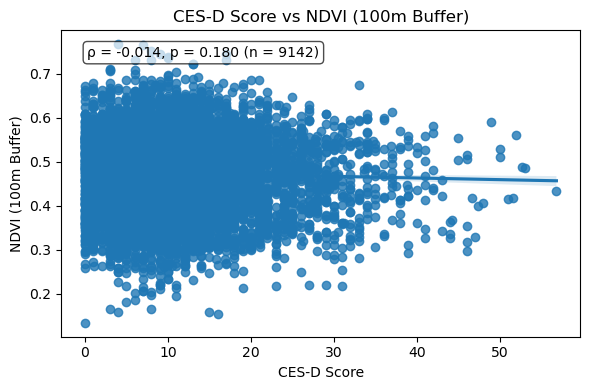


  CES-D Score  ×  NDVI (200m Buffer)
  x: CES-D Score
  y: NDVI (200m Buffer)
  method: pearson
  n: 9142
  correlation: -0.04461970256618115
  p_value: 1.9740868387474668e-05
  effect_size: 0.0019909178570944727
  effect_label: r² (variance explained)


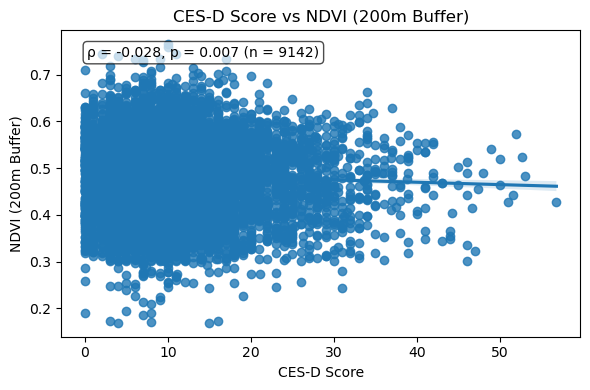


  CES-D Score  ×  NDVI (500m Buffer)
  x: CES-D Score
  y: NDVI (500m Buffer)
  method: pearson
  n: 9142
  correlation: -0.04532710881187126
  p_value: 1.4540733071679118e-05
  effect_size: 0.0020545467932432176
  effect_label: r² (variance explained)


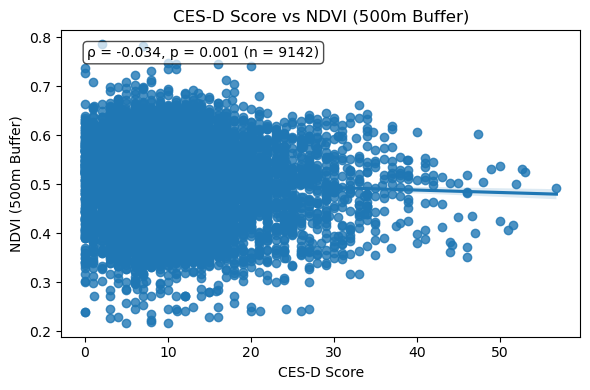


  CES-D Score  ×  NDVI (1000m Buffer)
  x: CES-D Score
  y: NDVI (1000m Buffer)
  method: pearson
  n: 9142
  correlation: -0.03988112719613876
  p_value: 0.00013663458292083693
  effect_size: 0.0015905043064345986
  effect_label: r² (variance explained)


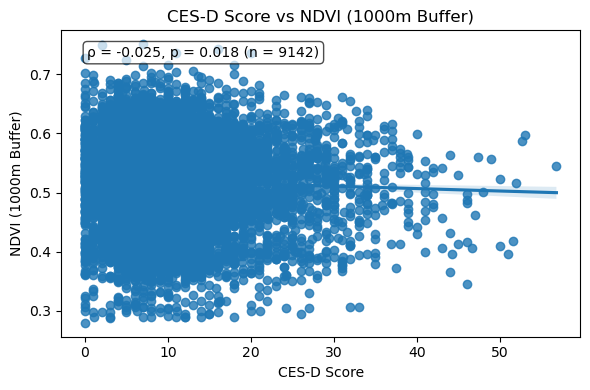


  GAD-7 Score  ×  NDVI (100m Buffer)
  x: GAD-7 Score
  y: NDVI (100m Buffer)
  method: pearson
  n: 9304
  correlation: -0.022734771451952077
  p_value: 0.028312986734055707
  effect_size: 0.0005168698329724951
  effect_label: r² (variance explained)


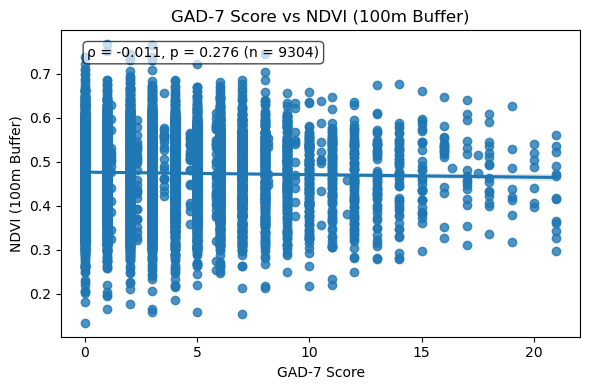


  GAD-7 Score  ×  NDVI (200m Buffer)
  x: GAD-7 Score
  y: NDVI (200m Buffer)
  method: pearson
  n: 9304
  correlation: -0.02484919726148425
  p_value: 0.016532940335540314
  effect_size: 0.0006174826045401564
  effect_label: r² (variance explained)


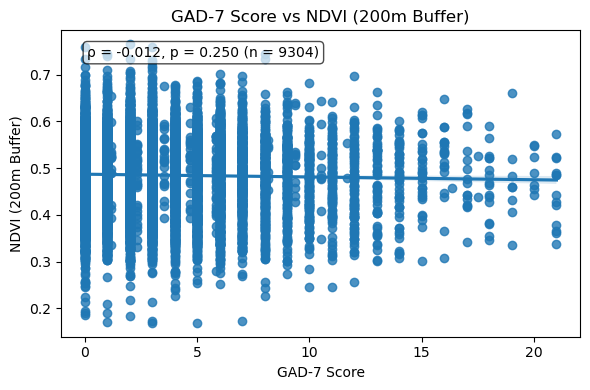


  GAD-7 Score  ×  NDVI (500m Buffer)
  x: GAD-7 Score
  y: NDVI (500m Buffer)
  method: pearson
  n: 9304
  correlation: -0.037197514153870265
  p_value: 0.0003322933459287709
  effect_size: 0.0013836550592273788
  effect_label: r² (variance explained)


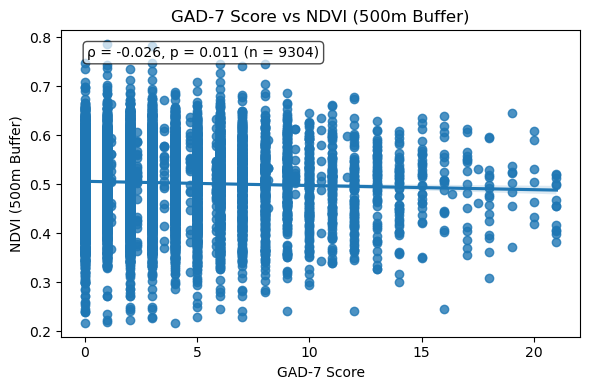


  GAD-7 Score  ×  NDVI (1000m Buffer)
  x: GAD-7 Score
  y: NDVI (1000m Buffer)
  method: pearson
  n: 9304
  correlation: -0.036798353126708594
  p_value: 0.00038494857717203106
  effect_size: 0.0013541187928379442
  effect_label: r² (variance explained)


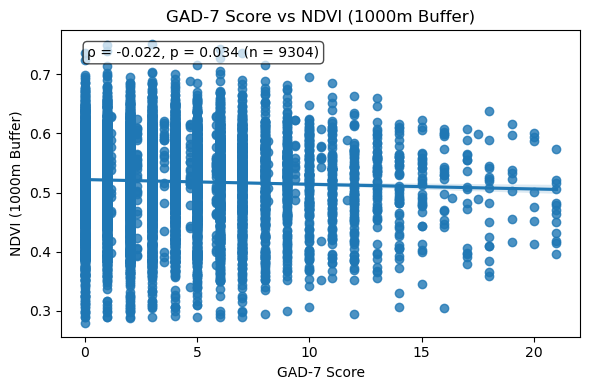


  SWLS Score  ×  NDVI (100m Buffer)
  x: SWLS Score
  y: NDVI (100m Buffer)
  method: pearson
  n: 9323
  correlation: 0.0962909373749123
  p_value: 1.1872362347845366e-20
  effect_size: 0.009271944620539282
  effect_label: r² (variance explained)


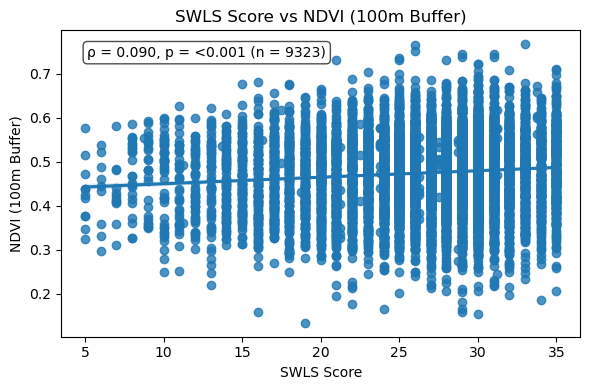


  SWLS Score  ×  NDVI (200m Buffer)
  x: SWLS Score
  y: NDVI (200m Buffer)
  method: pearson
  n: 9323
  correlation: 0.1074402411792577
  p_value: 2.4101197890266213e-25
  effect_size: 0.011543405424657061
  effect_label: r² (variance explained)


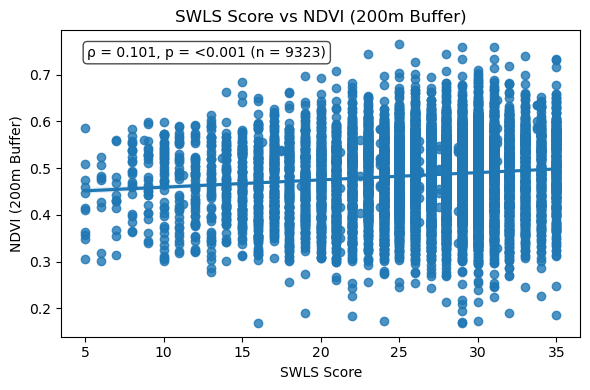


  SWLS Score  ×  NDVI (500m Buffer)
  x: SWLS Score
  y: NDVI (500m Buffer)
  method: pearson
  n: 9323
  correlation: 0.09471882351853243
  p_value: 4.9535473072884756e-20
  effect_size: 0.008971655528734893
  effect_label: r² (variance explained)


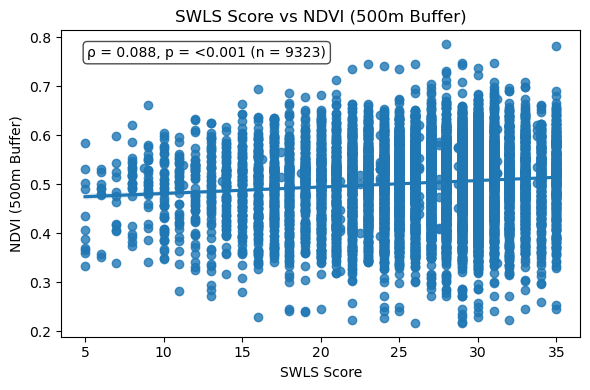


  SWLS Score  ×  NDVI (1000m Buffer)
  x: SWLS Score
  y: NDVI (1000m Buffer)
  method: pearson
  n: 9323
  correlation: 0.09269050864238887
  p_value: 3.022046623075286e-19
  effect_size: 0.008591530392384765
  effect_label: r² (variance explained)


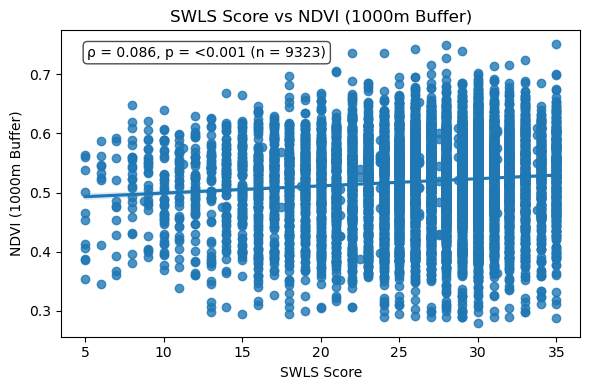

In [45]:
rows = []
for x_data in cols.mental_numeric:
    for y_data in cols.ndvi: #cols.greenspace_quartiles
        results = bivar.analyze_numeric_numeric(data, x=x_data, y=y_data, method="pearson")
        bivar.plot_numeric_numeric(data, x=x_data, y=y_data);

        rows.append(results)
        # --------------------------------------------------
        # Per-pair output: header → results → figure
        # --------------------------------------------------
        print(f"\n{'='*60}")
        print(f"  {x_data}  ×  {y_data}")
        print(f"{'='*60}")

        for key, val in results.items():
            if isinstance(val, pd.DataFrame):
                print(f"\n{key}:")
                print(val.to_string())
            elif val is not None:
                print(f"  {key}: {val}")

        plt.show()

df_corr_spatial = pd.DataFrame(rows)

In [46]:
df_corr_spatial

,x,y,method,n,correlation,p_value,effect_size,effect_label
0,CES-D Score,NDVI (100m Buffer),pearson,9142,-0.031186,2.862176e-03,0.000973,r² (variance explained)
1,CES-D Score,NDVI (200m Buffer),pearson,9142,-0.044620,1.974087e-05,0.001991,r² (variance explained)
2,CES-D Score,NDVI (500m Buffer),pearson,9142,-0.045327,1.454073e-05,0.002055,r² (variance explained)
3,CES-D Score,NDVI (1000m Buffer),pearson,9142,-0.039881,1.366346e-04,0.001591,r² (variance explained)
4,GAD-7 Score,NDVI (100m Buffer),pearson,9304,-0.022735,2.831299e-02,0.000517,r² (variance explained)
5,GAD-7 Score,NDVI (200m Buffer),pearson,9304,-0.024849,1.653294e-02,0.000617,r² (variance explained)
6,GAD-7 Score,NDVI (500m Buffer),pearson,9304,-0.037198,3.322933e-04,0.001384,r² (variance explained)
7,GAD-7 Score,NDVI (1000m Buffer),pearson,9304,-0.036798,3.849486e-04,0.001354,r² (variance explained)
8,SWLS Score,NDVI (100m Buffer),pearson,9323,0.096291,1.187236e-20,0.009272,r² (variance explained)
9,SWLS Score,NDVI (200m Buffer),pearson,9323,0.107440,2.410120e-25,0.011543,r² (variance explained)


## Correlation between Mental scores and Land-use-based green space (numeric) – Pearson


  CES-D Score  ×  green_100
  x: CES-D Score
  y: green_100
  method: pearson
  n: 9104
  correlation: -0.0214782600037377
  p_value: 0.04043272448522817
  effect_size: 0.0004613156527881586
  effect_label: r² (variance explained)


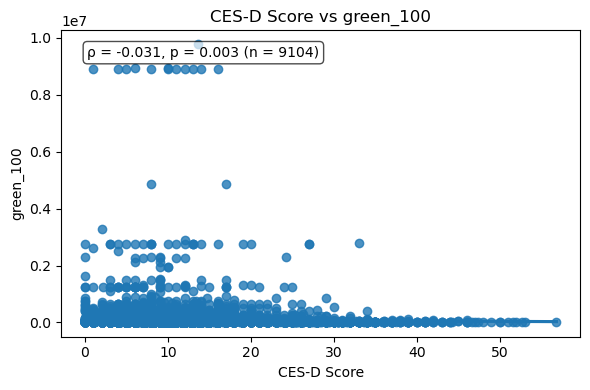


  CES-D Score  ×  green_200
  x: CES-D Score
  y: green_200
  method: pearson
  n: 9104
  correlation: -0.03802970878851788
  p_value: 0.000284064442590042
  effect_size: 0.0014462587505394738
  effect_label: r² (variance explained)


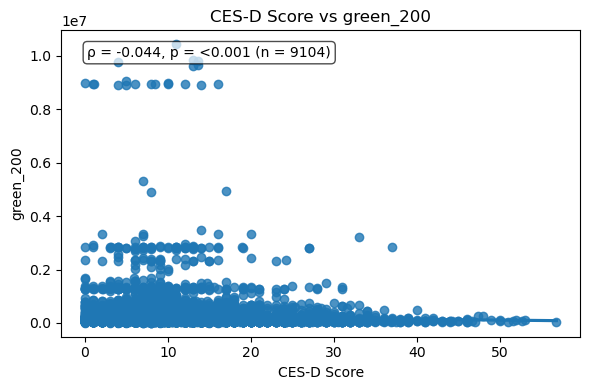


  CES-D Score  ×  green_500
  x: CES-D Score
  y: green_500
  method: pearson
  n: 9104
  correlation: -0.04202138641386494
  p_value: 6.054243224198406e-05
  effect_size: 0.0017657969161433533
  effect_label: r² (variance explained)


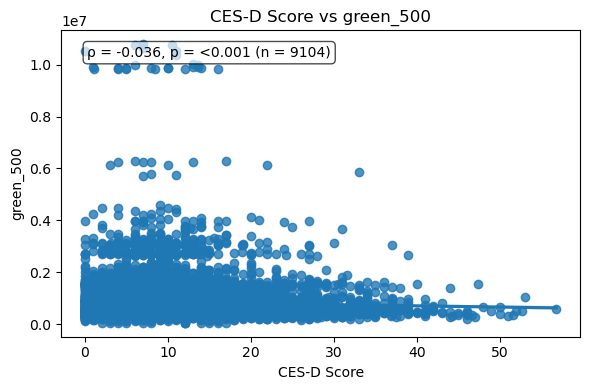


  CES-D Score  ×  green_1000
  x: CES-D Score
  y: green_1000
  method: pearson
  n: 9104
  correlation: -0.03677526150397069
  p_value: 0.0004487600399023466
  effect_size: 0.0013524198586854284
  effect_label: r² (variance explained)


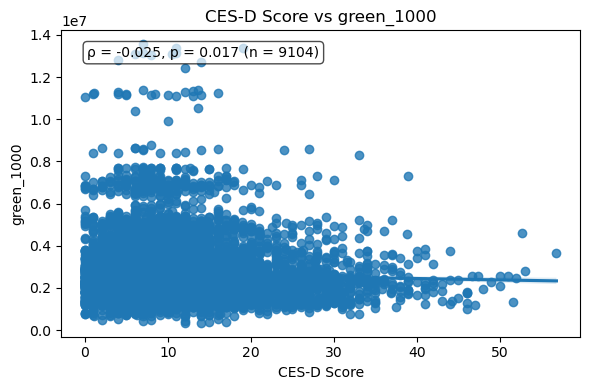


  GAD-7 Score  ×  green_100
  x: GAD-7 Score
  y: green_100
  method: pearson
  n: 9264
  correlation: -0.006265552642853432
  p_value: 0.5465206973827084
  effect_size: 3.9257149920367625e-05
  effect_label: r² (variance explained)


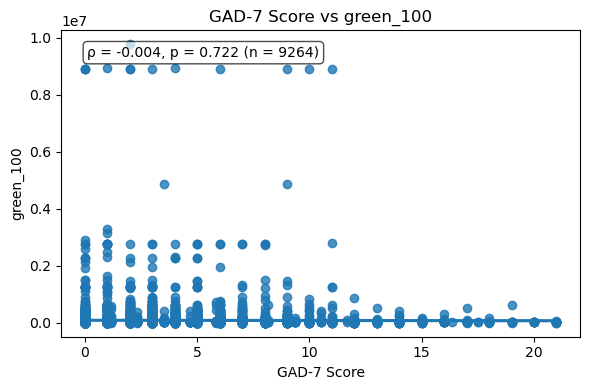


  GAD-7 Score  ×  green_200
  x: GAD-7 Score
  y: green_200
  method: pearson
  n: 9264
  correlation: -0.022180706820898278
  p_value: 0.03277241734764259
  effect_size: 0.0004919837550746434
  effect_label: r² (variance explained)


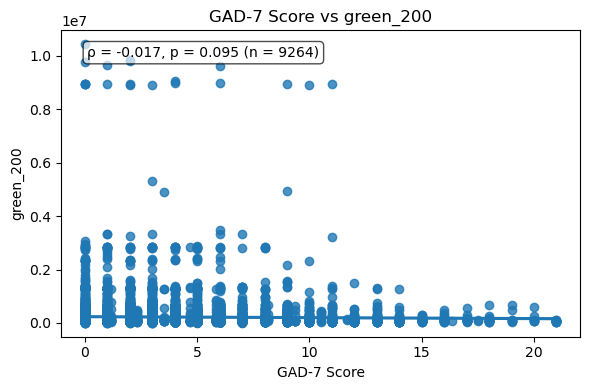


  GAD-7 Score  ×  green_500
  x: GAD-7 Score
  y: green_500
  method: pearson
  n: 9264
  correlation: -0.02773511634262522
  p_value: 0.007593052103753518
  effect_size: 0.0007692366785389565
  effect_label: r² (variance explained)


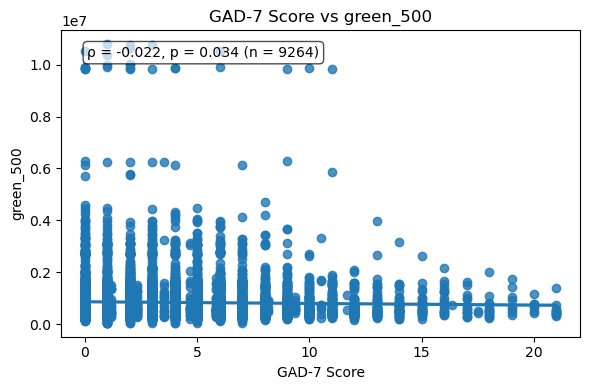


  GAD-7 Score  ×  green_1000
  x: GAD-7 Score
  y: green_1000
  method: pearson
  n: 9264
  correlation: -0.025405614106705637
  p_value: 0.014471291225784813
  effect_size: 0.0006454452281388405
  effect_label: r² (variance explained)


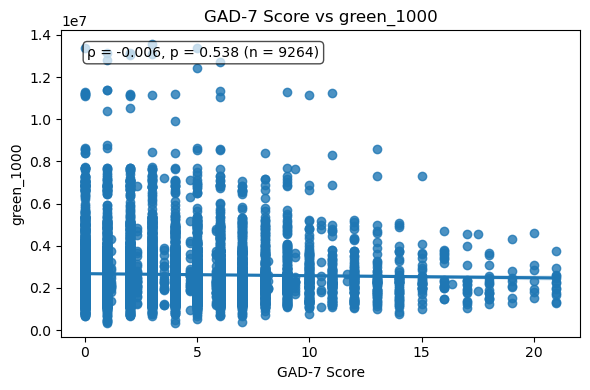


  SWLS Score  ×  green_100
  x: SWLS Score
  y: green_100
  method: pearson
  n: 9283
  correlation: 0.03348025330187208
  p_value: 0.0012542971964975024
  effect_size: 0.001120927361157516
  effect_label: r² (variance explained)


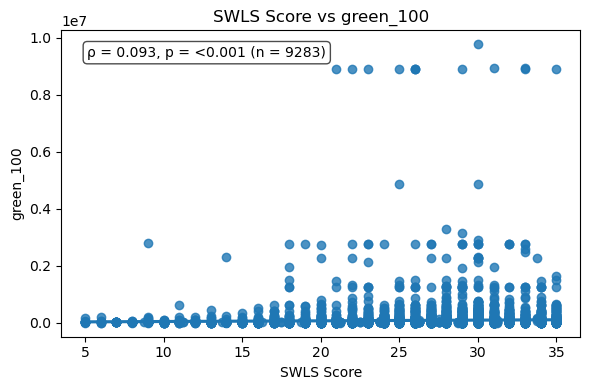


  SWLS Score  ×  green_200
  x: SWLS Score
  y: green_200
  method: pearson
  n: 9283
  correlation: 0.059013379377825075
  p_value: 1.2701426556739453e-08
  effect_size: 0.00348257894559111
  effect_label: r² (variance explained)


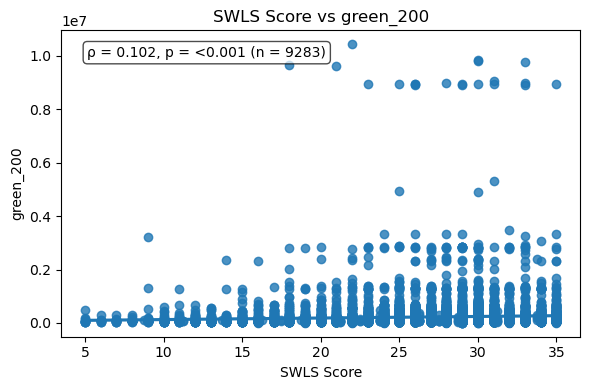


  SWLS Score  ×  green_500
  x: SWLS Score
  y: green_500
  method: pearson
  n: 9283
  correlation: 0.08368301908446064
  p_value: 6.703534878338809e-16
  effect_size: 0.007002847683090205
  effect_label: r² (variance explained)


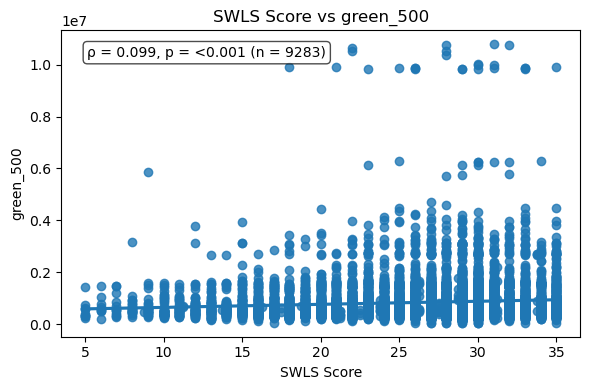


  SWLS Score  ×  green_1000
  x: SWLS Score
  y: green_1000
  method: pearson
  n: 9283
  correlation: 0.08947663078335658
  p_value: 5.7662610306020874e-18
  effect_size: 0.008006067456341113
  effect_label: r² (variance explained)


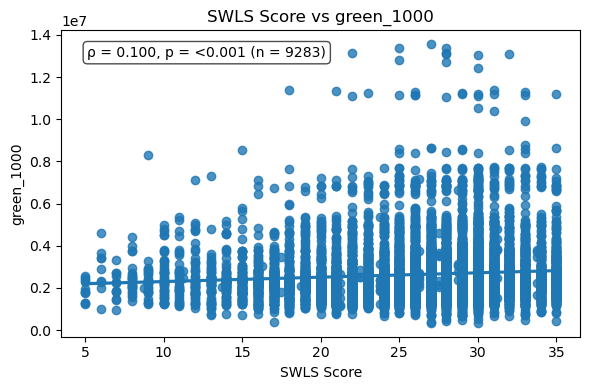

In [50]:
rows = []
for x_data in cols.mental_numeric:
    for y_data in cols.greenspace_raw:
        results = bivar.analyze_numeric_numeric(data, x=x_data, y=y_data, method="pearson")
        bivar.plot_numeric_numeric(data, x=x_data, y=y_data);

        rows.append(results)
        # --------------------------------------------------
        # Per-pair output: header → results → figure
        # --------------------------------------------------
        print(f"\n{'='*60}")
        print(f"  {x_data}  ×  {y_data}")
        print(f"{'='*60}")

        for key, val in results.items():
            if isinstance(val, pd.DataFrame):
                print(f"\n{key}:")
                print(val.to_string())
            elif val is not None:
                print(f"  {key}: {val}")

        plt.show()

df_corr_spatial = pd.DataFrame(rows)

In [51]:
df_corr_spatial

,x,y,method,n,correlation,p_value,effect_size,effect_label
0,CES-D Score,green_100,pearson,9104,-0.021478,4.043272e-02,0.000461,r² (variance explained)
1,CES-D Score,green_200,pearson,9104,-0.038030,2.840644e-04,0.001446,r² (variance explained)
2,CES-D Score,green_500,pearson,9104,-0.042021,6.054243e-05,0.001766,r² (variance explained)
3,CES-D Score,green_1000,pearson,9104,-0.036775,4.487600e-04,0.001352,r² (variance explained)
4,GAD-7 Score,green_100,pearson,9264,-0.006266,5.465207e-01,0.000039,r² (variance explained)
5,GAD-7 Score,green_200,pearson,9264,-0.022181,3.277242e-02,0.000492,r² (variance explained)
6,GAD-7 Score,green_500,pearson,9264,-0.027735,7.593052e-03,0.000769,r² (variance explained)
7,GAD-7 Score,green_1000,pearson,9264,-0.025406,1.447129e-02,0.000645,r² (variance explained)
8,SWLS Score,green_100,pearson,9283,0.033480,1.254297e-03,0.001121,r² (variance explained)
9,SWLS Score,green_200,pearson,9283,0.059013,1.270143e-08,0.003483,r² (variance explained)


## Correlation between Mental scores and Land-use-based green space (numeric) – Spearman


  CES-D Score  ×  green_100
  x: CES-D Score
  y: green_100
  method: spearman
  n: 9104
  correlation: -0.031421170861857174
  p_value: 0.0027142259992494313
  effect_size: -0.031421170861857174
  effect_label: rho (Spearman)


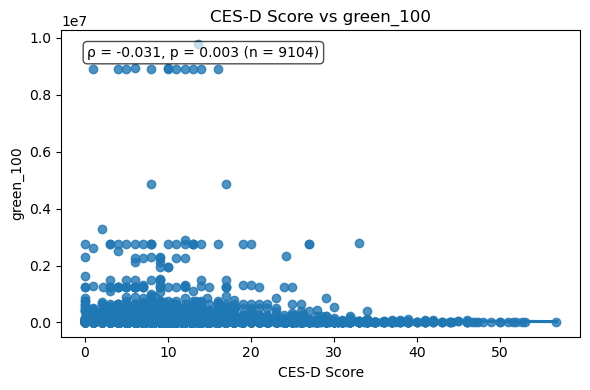


  CES-D Score  ×  green_200
  x: CES-D Score
  y: green_200
  method: spearman
  n: 9104
  correlation: -0.04356693880373368
  p_value: 3.205715608685345e-05
  effect_size: -0.04356693880373368
  effect_label: rho (Spearman)


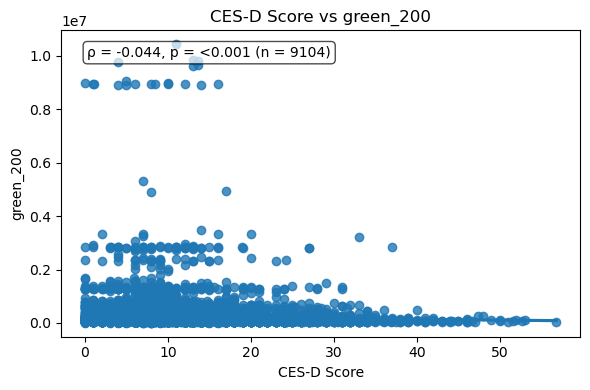


  CES-D Score  ×  green_500
  x: CES-D Score
  y: green_500
  method: spearman
  n: 9104
  correlation: -0.036365613109586886
  p_value: 0.0005195055408266191
  effect_size: -0.036365613109586886
  effect_label: rho (Spearman)


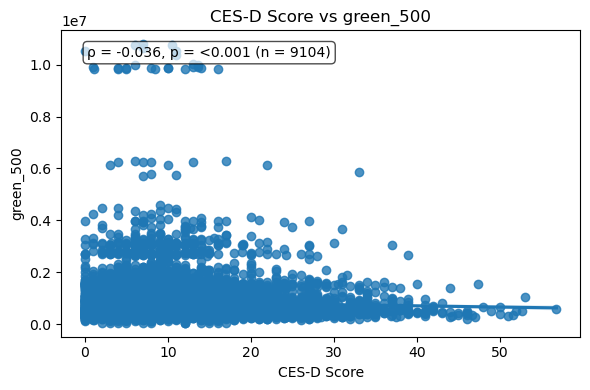


  CES-D Score  ×  green_1000
  x: CES-D Score
  y: green_1000
  method: spearman
  n: 9104
  correlation: -0.02506893139036356
  p_value: 0.016756996975961294
  effect_size: -0.02506893139036356
  effect_label: rho (Spearman)


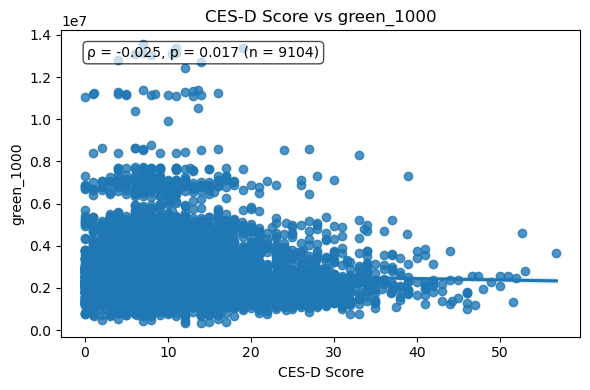


  GAD-7 Score  ×  green_100
  x: GAD-7 Score
  y: green_100
  method: spearman
  n: 9264
  correlation: -0.0036903783902940863
  p_value: 0.722476470511208
  effect_size: -0.0036903783902940863
  effect_label: rho (Spearman)


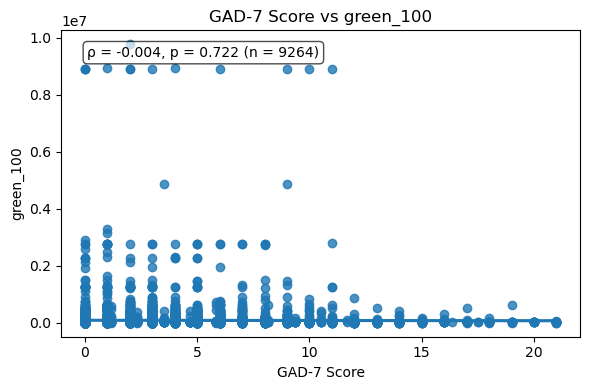


  GAD-7 Score  ×  green_200
  x: GAD-7 Score
  y: green_200
  method: spearman
  n: 9264
  correlation: -0.017367748120584982
  p_value: 0.09461494429718244
  effect_size: -0.017367748120584982
  effect_label: rho (Spearman)


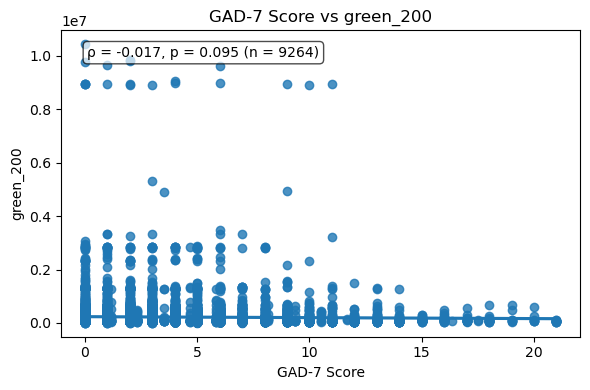


  GAD-7 Score  ×  green_500
  x: GAD-7 Score
  y: green_500
  method: spearman
  n: 9264
  correlation: -0.02203096709500701
  p_value: 0.03396856631841585
  effect_size: -0.02203096709500701
  effect_label: rho (Spearman)


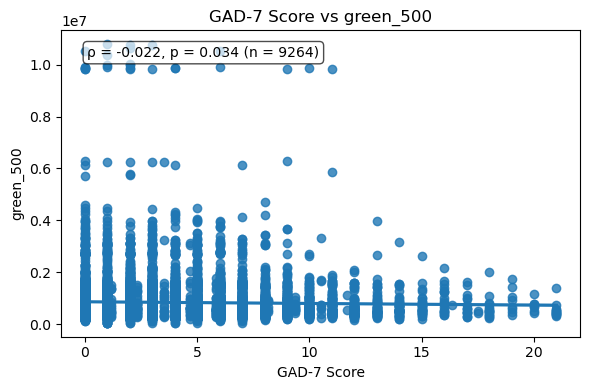


  GAD-7 Score  ×  green_1000
  x: GAD-7 Score
  y: green_1000
  method: spearman
  n: 9264
  correlation: -0.006391723811335371
  p_value: 0.5384724309972717
  effect_size: -0.006391723811335371
  effect_label: rho (Spearman)


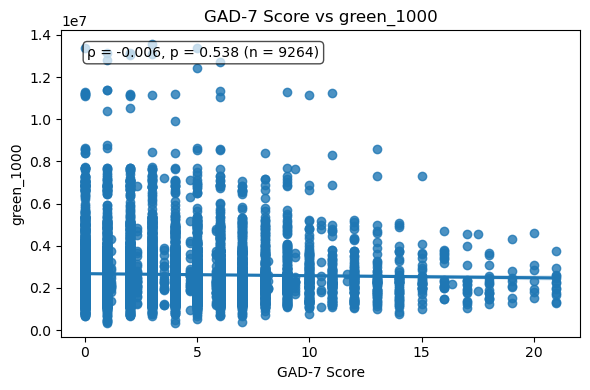


  SWLS Score  ×  green_100
  x: SWLS Score
  y: green_100
  method: spearman
  n: 9283
  correlation: 0.09293587142697367
  p_value: 2.9003578363268148e-19
  effect_size: 0.09293587142697367
  effect_label: rho (Spearman)


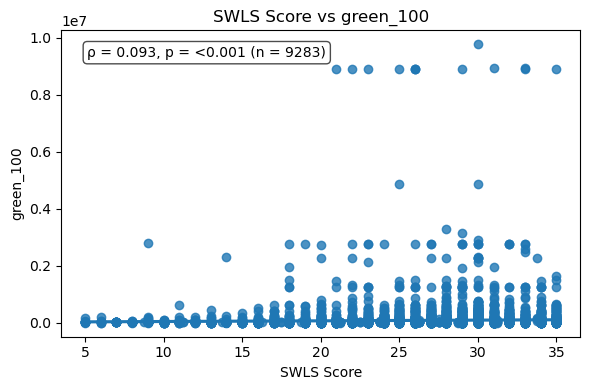


  SWLS Score  ×  green_200
  x: SWLS Score
  y: green_200
  method: spearman
  n: 9283
  correlation: 0.1020812404756273
  p_value: 6.217486940898478e-23
  effect_size: 0.1020812404756273
  effect_label: rho (Spearman)


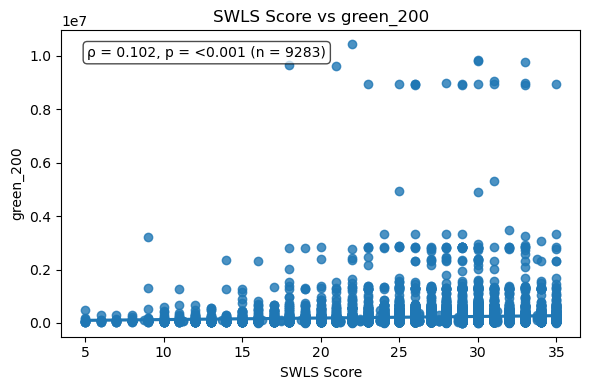


  SWLS Score  ×  green_500
  x: SWLS Score
  y: green_500
  method: spearman
  n: 9283
  correlation: 0.09918887666225812
  p_value: 9.796614733359467e-22
  effect_size: 0.09918887666225812
  effect_label: rho (Spearman)


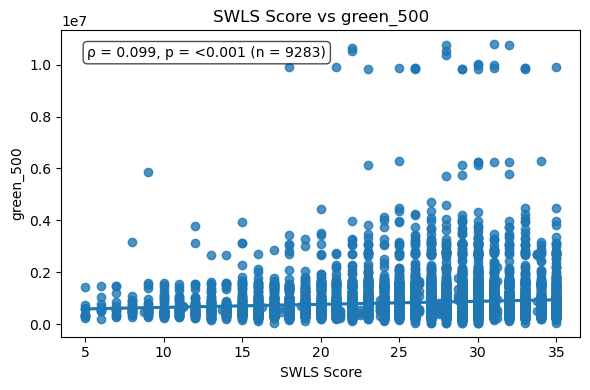


  SWLS Score  ×  green_1000
  x: SWLS Score
  y: green_1000
  method: spearman
  n: 9283
  correlation: 0.10027022563632058
  p_value: 3.527101102818989e-22
  effect_size: 0.10027022563632058
  effect_label: rho (Spearman)


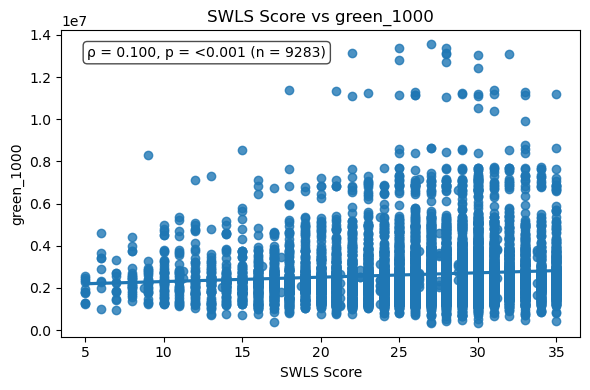

In [52]:
rows = []
for x_data in cols.mental_numeric:
    for y_data in cols.greenspace_raw:
        results = bivar.analyze_numeric_numeric(data, x=x_data, y=y_data, method="spearman")
        bivar.plot_numeric_numeric(data, x=x_data, y=y_data);

        rows.append(results)
        # --------------------------------------------------
        # Per-pair output: header → results → figure
        # --------------------------------------------------
        print(f"\n{'='*60}")
        print(f"  {x_data}  ×  {y_data}")
        print(f"{'='*60}")

        for key, val in results.items():
            if isinstance(val, pd.DataFrame):
                print(f"\n{key}:")
                print(val.to_string())
            elif val is not None:
                print(f"  {key}: {val}")

        plt.show()

df_corr_spatial = pd.DataFrame(rows)

In [53]:
df_corr_spatial

,x,y,method,n,correlation,p_value,effect_size,effect_label
0,CES-D Score,green_100,spearman,9104,-0.031421,2.714226e-03,-0.031421,rho (Spearman)
1,CES-D Score,green_200,spearman,9104,-0.043567,3.205716e-05,-0.043567,rho (Spearman)
2,CES-D Score,green_500,spearman,9104,-0.036366,5.195055e-04,-0.036366,rho (Spearman)
3,CES-D Score,green_1000,spearman,9104,-0.025069,1.675700e-02,-0.025069,rho (Spearman)
4,GAD-7 Score,green_100,spearman,9264,-0.003690,7.224765e-01,-0.003690,rho (Spearman)
5,GAD-7 Score,green_200,spearman,9264,-0.017368,9.461494e-02,-0.017368,rho (Spearman)
6,GAD-7 Score,green_500,spearman,9264,-0.022031,3.396857e-02,-0.022031,rho (Spearman)
7,GAD-7 Score,green_1000,spearman,9264,-0.006392,5.384724e-01,-0.006392,rho (Spearman)
8,SWLS Score,green_100,spearman,9283,0.092936,2.900358e-19,0.092936,rho (Spearman)
9,SWLS Score,green_200,spearman,9283,0.102081,6.217487e-23,0.102081,rho (Spearman)


## Correlation between Mental scores and Land-use-based green space (categorical) – Spearman


  CES-D Score  ×  Green Space Quartile (100m Buffer)
  x: CES-D Score
  y: Green Space Quartile (100m Buffer)
  method: spearman
  n: 9104
  correlation: -0.03114266929399107
  p_value: 0.0029607208949902824
  effect_size: -0.03114266929399107
  effect_label: rho (Spearman)


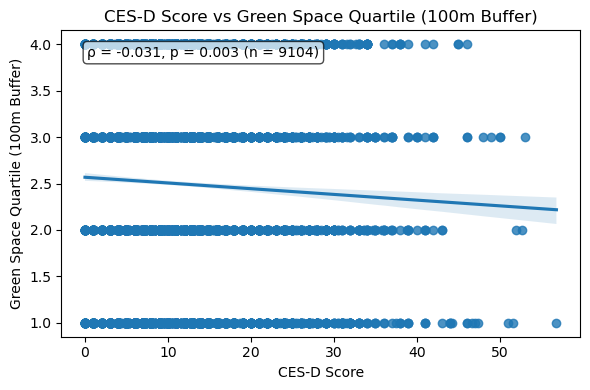


  CES-D Score  ×  Green Space Quartile (200m Buffer)
  x: CES-D Score
  y: Green Space Quartile (200m Buffer)
  method: spearman
  n: 9104
  correlation: -0.04204658525164526
  p_value: 5.9928086643556295e-05
  effect_size: -0.04204658525164526
  effect_label: rho (Spearman)


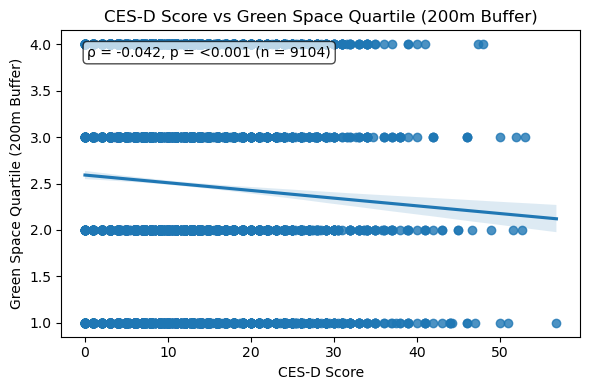


  CES-D Score  ×  Green Space Quartile (500m Buffer)
  x: CES-D Score
  y: Green Space Quartile (500m Buffer)
  method: spearman
  n: 9104
  correlation: -0.037784787503328955
  p_value: 0.00031092477569018593
  effect_size: -0.037784787503328955
  effect_label: rho (Spearman)


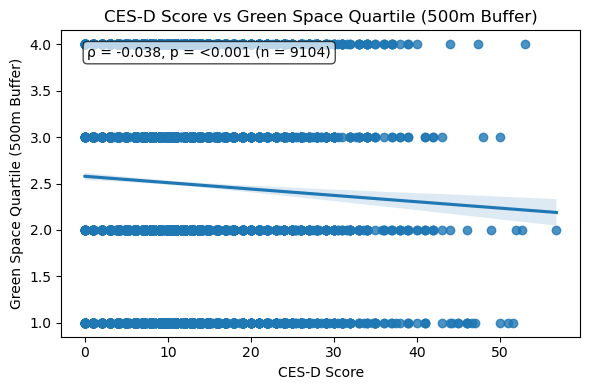


  CES-D Score  ×  Green Space Quartile (1000m Buffer)
  x: CES-D Score
  y: Green Space Quartile (1000m Buffer)
  method: spearman
  n: 9104
  correlation: -0.020546277060883168
  p_value: 0.04995391873624373
  effect_size: -0.020546277060883168
  effect_label: rho (Spearman)


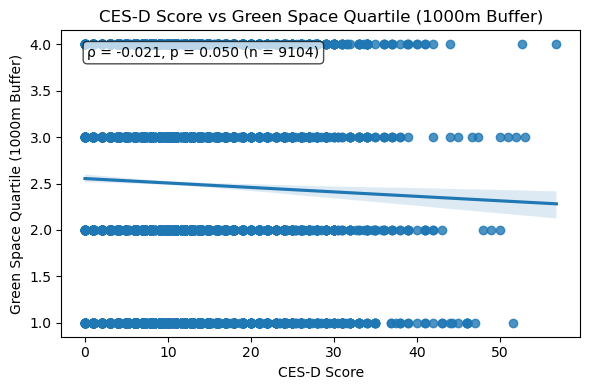


  GAD-7 Score  ×  Green Space Quartile (100m Buffer)
  x: GAD-7 Score
  y: Green Space Quartile (100m Buffer)
  method: spearman
  n: 9264
  correlation: -0.004588421299024989
  p_value: 0.6587954820147768
  effect_size: -0.004588421299024989
  effect_label: rho (Spearman)


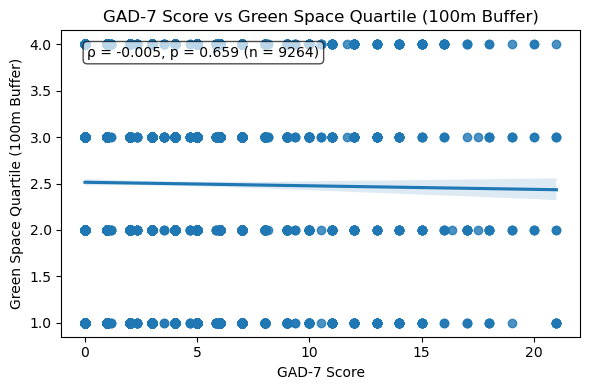


  GAD-7 Score  ×  Green Space Quartile (200m Buffer)
  x: GAD-7 Score
  y: Green Space Quartile (200m Buffer)
  method: spearman
  n: 9264
  correlation: -0.02016726314594225
  p_value: 0.05225488260399601
  effect_size: -0.02016726314594225
  effect_label: rho (Spearman)


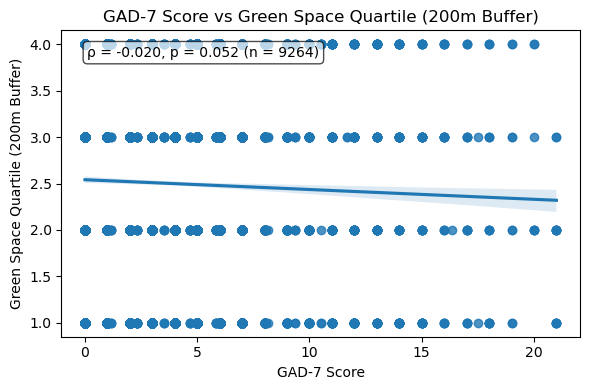


  GAD-7 Score  ×  Green Space Quartile (500m Buffer)
  x: GAD-7 Score
  y: Green Space Quartile (500m Buffer)
  method: spearman
  n: 9264
  correlation: -0.02407369991807779
  p_value: 0.020497799726543066
  effect_size: -0.02407369991807779
  effect_label: rho (Spearman)


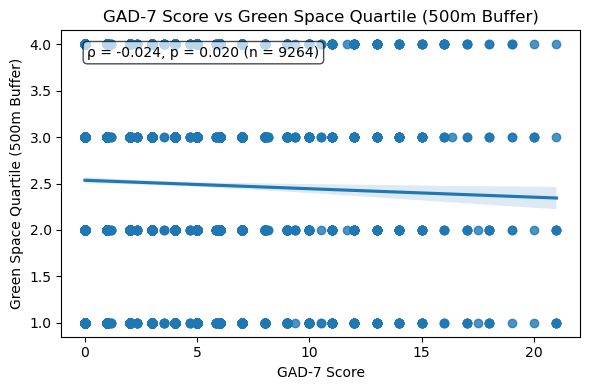


  GAD-7 Score  ×  Green Space Quartile (1000m Buffer)
  x: GAD-7 Score
  y: Green Space Quartile (1000m Buffer)
  method: spearman
  n: 9264
  correlation: -0.008122847805395227
  p_value: 0.4343739367372127
  effect_size: -0.008122847805395227
  effect_label: rho (Spearman)


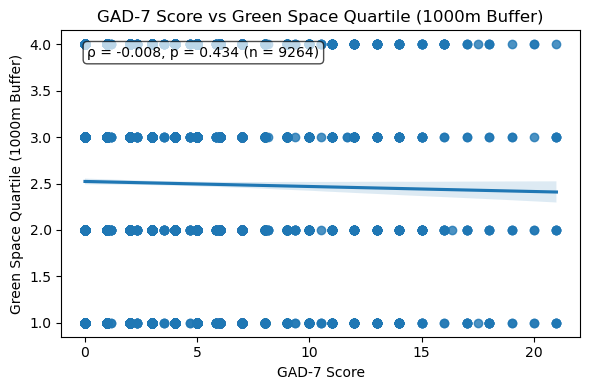


  SWLS Score  ×  Green Space Quartile (100m Buffer)
  x: SWLS Score
  y: Green Space Quartile (100m Buffer)
  method: spearman
  n: 9283
  correlation: 0.09189079788569395
  p_value: 7.242325672580076e-19
  effect_size: 0.09189079788569395
  effect_label: rho (Spearman)


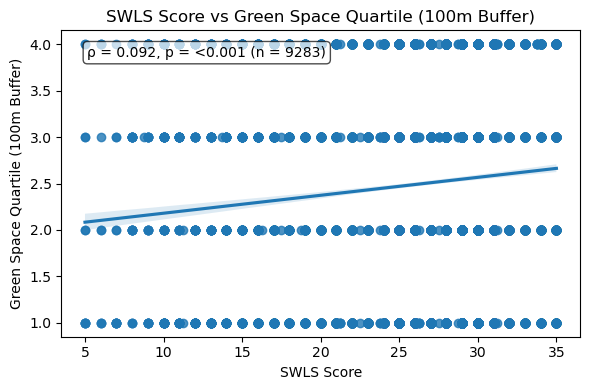


  SWLS Score  ×  Green Space Quartile (200m Buffer)
  x: SWLS Score
  y: Green Space Quartile (200m Buffer)
  method: spearman
  n: 9283
  correlation: 0.09959770434916372
  p_value: 6.666633905695611e-22
  effect_size: 0.09959770434916372
  effect_label: rho (Spearman)


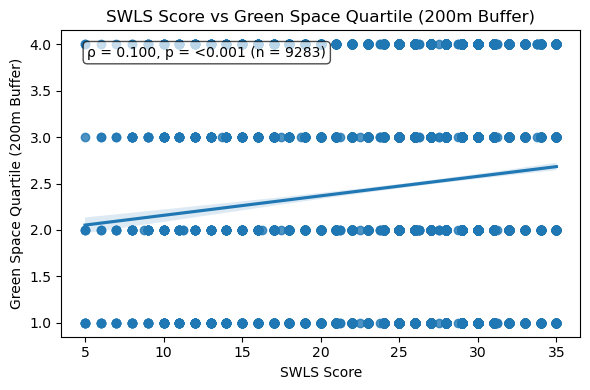


  SWLS Score  ×  Green Space Quartile (500m Buffer)
  x: SWLS Score
  y: Green Space Quartile (500m Buffer)
  method: spearman
  n: 9283
  correlation: 0.0949229277904191
  p_value: 4.9485617177312136e-20
  effect_size: 0.0949229277904191
  effect_label: rho (Spearman)


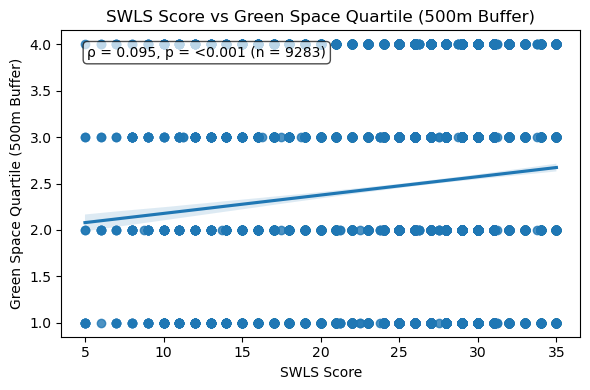


  SWLS Score  ×  Green Space Quartile (1000m Buffer)
  x: SWLS Score
  y: Green Space Quartile (1000m Buffer)
  method: spearman
  n: 9283
  correlation: 0.0973924149026546
  p_value: 5.2180668511571106e-21
  effect_size: 0.0973924149026546
  effect_label: rho (Spearman)


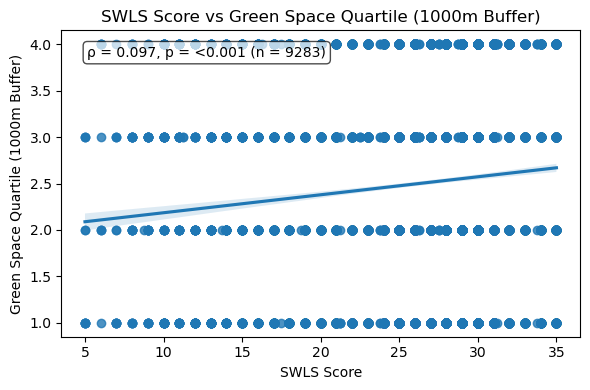

In [54]:
rows = []
for x_data in cols.mental_numeric:
    for y_data in cols.greenspace_quartiles:
        results = bivar.analyze_numeric_numeric(data, x=x_data, y=y_data, method="spearman")
        bivar.plot_numeric_numeric(data, x=x_data, y=y_data);

        rows.append(results)
        # --------------------------------------------------
        # Per-pair output: header → results → figure
        # --------------------------------------------------
        print(f"\n{'='*60}")
        print(f"  {x_data}  ×  {y_data}")
        print(f"{'='*60}")

        for key, val in results.items():
            if isinstance(val, pd.DataFrame):
                print(f"\n{key}:")
                print(val.to_string())
            elif val is not None:
                print(f"  {key}: {val}")

        plt.show()

df_corr_spatial = pd.DataFrame(rows)

In [55]:
df_corr_spatial

,x,y,method,n,correlation,p_value,effect_size,effect_label
0,CES-D Score,Green Space Quartile (100m Buffer),spearman,9104,-0.031143,2.960721e-03,-0.031143,rho (Spearman)
1,CES-D Score,Green Space Quartile (200m Buffer),spearman,9104,-0.042047,5.992809e-05,-0.042047,rho (Spearman)
2,CES-D Score,Green Space Quartile (500m Buffer),spearman,9104,-0.037785,3.109248e-04,-0.037785,rho (Spearman)
3,CES-D Score,Green Space Quartile (1000m Buffer),spearman,9104,-0.020546,4.995392e-02,-0.020546,rho (Spearman)
4,GAD-7 Score,Green Space Quartile (100m Buffer),spearman,9264,-0.004588,6.587955e-01,-0.004588,rho (Spearman)
5,GAD-7 Score,Green Space Quartile (200m Buffer),spearman,9264,-0.020167,5.225488e-02,-0.020167,rho (Spearman)
6,GAD-7 Score,Green Space Quartile (500m Buffer),spearman,9264,-0.024074,2.049780e-02,-0.024074,rho (Spearman)
7,GAD-7 Score,Green Space Quartile (1000m Buffer),spearman,9264,-0.008123,4.343739e-01,-0.008123,rho (Spearman)
8,SWLS Score,Green Space Quartile (100m Buffer),spearman,9283,0.091891,7.242326e-19,0.091891,rho (Spearman)
9,SWLS Score,Green Space Quartile (200m Buffer),spearman,9283,0.099598,6.666634e-22,0.099598,rho (Spearman)
